# Supervivencia del Titanic — Semana 2
## Árbol de Decisión · Bosque Aleatorio · SVM · Red Neuronal Artificial
### Aprendizaje Automático Estadístico · MCDA-B · Deber Semana 2

**Asignatura:** Aprendizaje automático estadístico MIA-B  
**Docente:** Ivan Danilo Garcia Santillan  
**Universidad:** UIDE  
**Grupo 1:**
- César Nelson Abarca Araujo
- Nataly Fernanda Lanchimba Caiza
- Jhon Enrique Oña Guamani

**Dataset:** `titanic_train.csv` / `titanic_test.csv`  
**Algoritmos Fase I:** Árbol de Decisión · Bosque Aleatorio · SVM  
**Algoritmos Fase II:** Red Neuronal Artificial (TensorFlow/Keras)  
**Repositorio GitHub:** [UIDE MIAA-B · Aprendizaje Automático Estadístico · Semana 2 · Tarea G1](https://github.com/cnabarca/Maestria-IA-UIDE/tree/main/5.%20Aprendizaje%20Automatico%20Estadistico/Semana%202/Tarea%20G1)

---

## Descripción del Problema

**Objetivo:** Clasificar si un pasajero del Titanic **sobrevivió (1)** o **no sobrevivió (0)** al naufragio del 15 de abril de 1912, comparando cuatro algoritmos de clasificación de distinta naturaleza.

| Fase | Algoritmo | Tipo | Biblioteca |
|---|---|---|---|
| **I** | Árbol de Decisión | Basado en reglas / interpretable | scikit-learn |
| **I** | Bosque Aleatorio | Ensemble de árboles | scikit-learn |
| **I** | SVM | Margen máximo / kernel trick | scikit-learn |
| **II** | Red Neuronal Artificial | Aprendizaje profundo | TensorFlow / Keras |

**Fases del trabajo:**

| Fase | Contenido |
|---|---|
| **Fase I** | Carga · Preprocesamiento · EDA · DT · RF · SVM |
| **Fase II** | RNA (TF/Keras) · Curvas de aprendizaje · Comparativa final |

---
# Fase I
## 1.1 Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

# Scikit-learn — preprocesamiento y evaluación
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    r2_score
)

# Scikit-learn — modelos Fase I
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# TensorFlow / Keras — modelo Fase II
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import joblib

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print('TensorFlow:', tf.__version__)
print('Librerías cargadas correctamente.')

TensorFlow: 2.21.0
Librerías cargadas correctamente.


## 1.2 Información del Dataset

| Atributo | Detalle |
|---|---|
| Fuente | Kaggle — Titanic: Machine Learning from Disaster |
| Instancias (train) | 891 pasajeros |
| Instancias (test) | 418 pasajeros |
| Variables | 12 (ID + target + 10 features) |
| Clases | No sobrevivió: 549 (61.6%) · Sobrevivió: 342 (38.4%) |
| Tipo de tarea | Clasificación binaria supervisada |

## 1.3 Diccionario de Variables

| Variable | Descripción | Tipo | Notas |
|---|---|---|---|
| `PassengerId` | Identificador único | Numérica | Se eliminará |
| `Survived` | **Target**: 1=sobrevivió, 0=no | Binaria | **Target** |
| `Pclass` | Clase del boleto (1/2/3) | Ordinal | Proxy socioeconómico |
| `Name` | Nombre del pasajero | Texto | Se eliminará |
| `Sex` | Género (male/female) | Categórica | Se codificará (0/1) |
| `Age` | Edad en años | Numérica | 177 nulos — se imputará |
| `SibSp` | Hermanos/cónyuge a bordo | Numérica | — |
| `Parch` | Padres/hijos a bordo | Numérica | — |
| `Ticket` | Número de billete | Texto | Se eliminará |
| `Fare` | Precio del billete | Numérica | — |
| `Cabin` | Número de cabina | Texto | 77% nulos — se eliminará |
| `Embarked` | Puerto de embarque (S/C/Q) | Categórica | Se codificará (0/1/2) |

## 1.4 Carga de Datos

In [35]:
BASE_PATH = r'C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 1\PROFESOR_AUE'

df_train = pd.read_csv(f'{BASE_PATH}\\titanic_train.csv')
df_test  = pd.read_csv(f'{BASE_PATH}\\titanic_test.csv')

print(f'Train: {df_train.shape}  |  Test: {df_test.shape}')
print('\nPrimeras filas — Train:')
display(df_train.head())

Train: (891, 12)  |  Test: (418, 11)

Primeras filas — Train:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1.5 Entendimiento de los Datos

Se examina la estructura, tipos de datos, valores faltantes y estadísticas básicas.

In [36]:
print('=== TIPOS DE DATOS (Train) ===')
df_train.info()

print('\n=== VALORES FALTANTES ===')
missing = pd.DataFrame({
    'Train (n)' : df_train.isnull().sum(),
    'Train (%)'  : (df_train.isnull().mean() * 100).round(1),
    'Test (n)'  : df_test.isnull().sum(),
    'Test (%)'   : (df_test.isnull().mean() * 100).round(1)
})
display(missing[missing['Train (n)'] + missing['Test (n)'] > 0])

print('\n=== ESTADÍSTICAS DESCRIPTIVAS (Train) ===')
display(df_train.describe())

=== TIPOS DE DATOS (Train) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

=== VALORES FALTANTES ===


,Train (n),Train (%),Test (n),Test (%)
Age,177,19.9,86.0,20.6
Cabin,687,77.1,327.0,78.2
Embarked,2,0.2,0.0,0.0
Fare,0,0.0,1.0,0.2



=== ESTADÍSTICAS DESCRIPTIVAS (Train) ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 1.6 Preprocesamiento de Datos

| Paso | Variable | Acción | Motivo |
|---|---|---|---|
| 1 | `Sex` | Codificación (female=0, male=1) | Algoritmos requieren entradas numéricas |
| 2 | `Embarked` | Codificación (Q=0, S=1, C=2) | Ídem |
| 3 | `Age` | Imputación con media (~30) | 19.9% valores nulos |
| 4 | `Age` | Discretización en 7 rangos etarios | Capturar patrones por grupo |
| 5 | `Cabin` | Eliminación | 77% nulos — inviable |
| 6 | `PassengerId`, `Name`, `Ticket` | Eliminación | Sin poder predictivo |
| 7 | Filas | Eliminación de nulos residuales | Limpiar `Embarked` |

| Categoría `Age` | Rango | Grupo |
|---|---|---|
| 1 | 0–8 | Niños |
| 2 | 9–15 | Adolescentes tempranos |
| 3 | 16–18 | Adolescentes |
| 4 | 19–25 | Jóvenes adultos |
| 5 | 26–40 | Adultos |
| 6 | 41–60 | Adultos mayores |
| 7 | 61–100 | Tercera edad |

In [37]:
# Paso 1-2: Codificación categórica
df_train['Sex']      = df_train['Sex'].map({'female': 0, 'male': 1})
df_test['Sex']       = df_test['Sex'].map({'female': 0, 'male': 1})
df_train['Embarked'] = df_train['Embarked'].map({'Q': 0, 'S': 1, 'C': 2})
df_test['Embarked']  = df_test['Embarked'].map({'Q': 0, 'S': 1, 'C': 2})

# Paso 3: Imputación de Age
PROMEDIO = 30
df_train['Age'] = pd.to_numeric(df_train['Age'], errors='coerce').fillna(PROMEDIO)
df_test['Age']  = pd.to_numeric(df_test['Age'],  errors='coerce').fillna(PROMEDIO)

# Paso 4: Discretización de Age
bins  = [0, 8, 15, 18, 25, 40, 60, 100]
names = ['1', '2', '3', '4', '5', '6', '7']
df_train['Age'] = pd.cut(df_train['Age'], bins=bins, labels=names)
df_test['Age']  = pd.cut(df_test['Age'],  bins=bins, labels=names)

# Pasos 5-6: Eliminación de columnas
drop_train = [c for c in ['Cabin','PassengerId','Name','Ticket'] if c in df_train.columns]
drop_test  = [c for c in ['Cabin','Name','Ticket']               if c in df_test.columns]
df_train = df_train.drop(drop_train, axis=1)
df_test  = df_test.drop(drop_test,  axis=1)

# Paso 7: Eliminar nulos residuales
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

print('=== VERIFICACIÓN POST-PREPROCESAMIENTO ===')
print(f'Dimensiones — Train: {df_train.shape}  |  Test: {df_test.shape}')
print(f'Nulos restantes — Train: {df_train.isnull().sum().sum()}')
print('\nDataset depurado (primeras filas):')
display(df_train.head())

=== VERIFICACIÓN POST-PREPROCESAMIENTO ===
Dimensiones — Train: (889, 8)  |  Test: (417, 8)
Nulos restantes — Train: 0

Dataset depurado (primeras filas):


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,4,1,0,7.2500,1.0
1,1,1,0,5,1,0,71.2833,2.0
2,1,3,0,5,0,0,7.9250,1.0
3,1,1,0,5,1,0,53.1000,1.0
4,0,3,1,5,0,0,8.0500,1.0


---
## 1.7 Análisis Exploratorio de Datos (EDA)

El EDA permite identificar patrones, distribuciones y relaciones entre variables antes del modelado. Todo el análisis se realiza sobre el **dataset ya depurado**.

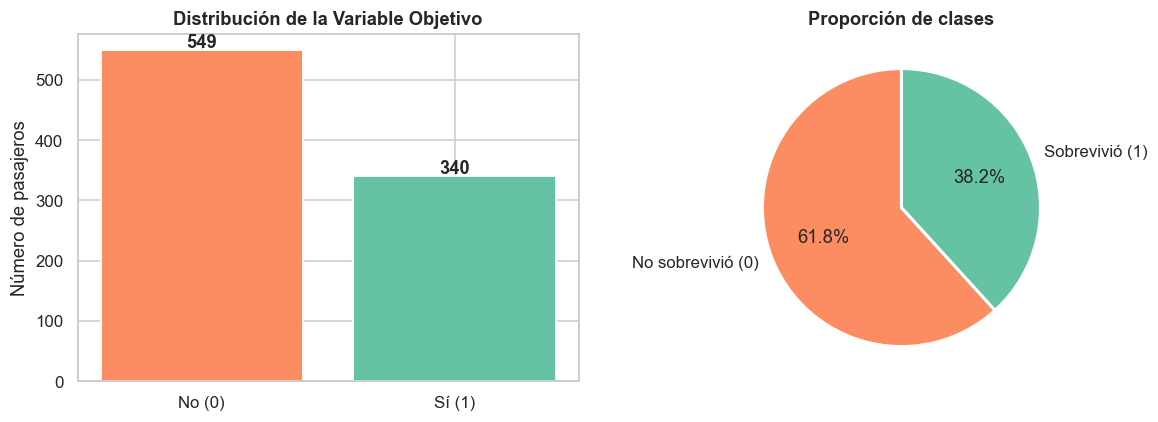

Conteo: {0: 549, 1: 340}


In [38]:
# Distribución de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df_train['Survived'].value_counts()
colors = ['#FC8D62', '#66C2A5']

axes[0].bar(['No (0)', 'Sí (1)'], counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución de la Variable Objetivo', fontweight='bold')
axes[0].set_ylabel('Número de pasajeros')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

counts.plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
            labels=['No sobrevivió (0)', 'Sobrevivió (1)'], colors=colors,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporción de clases', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()
print('Conteo:', counts.to_dict())

## Interpretación

La variable objetivo presenta una distribución moderadamente desbalanceada. Del total de observaciones, 549 pasajeros (61,8%) no sobrevivieron, mientras que 340 pasajeros (38,2%) sobrevivieron. Aunque la clase negativa es predominante, la diferencia entre ambas categorías no es suficientemente elevada como para considerarse un problema severo de desbalance. Por tanto, los algoritmos de clasificación pueden entrenarse adecuadamente; no obstante, se recomienda complementar la evaluación del desempeño mediante métricas enfocadas en la clase minoritaria. 

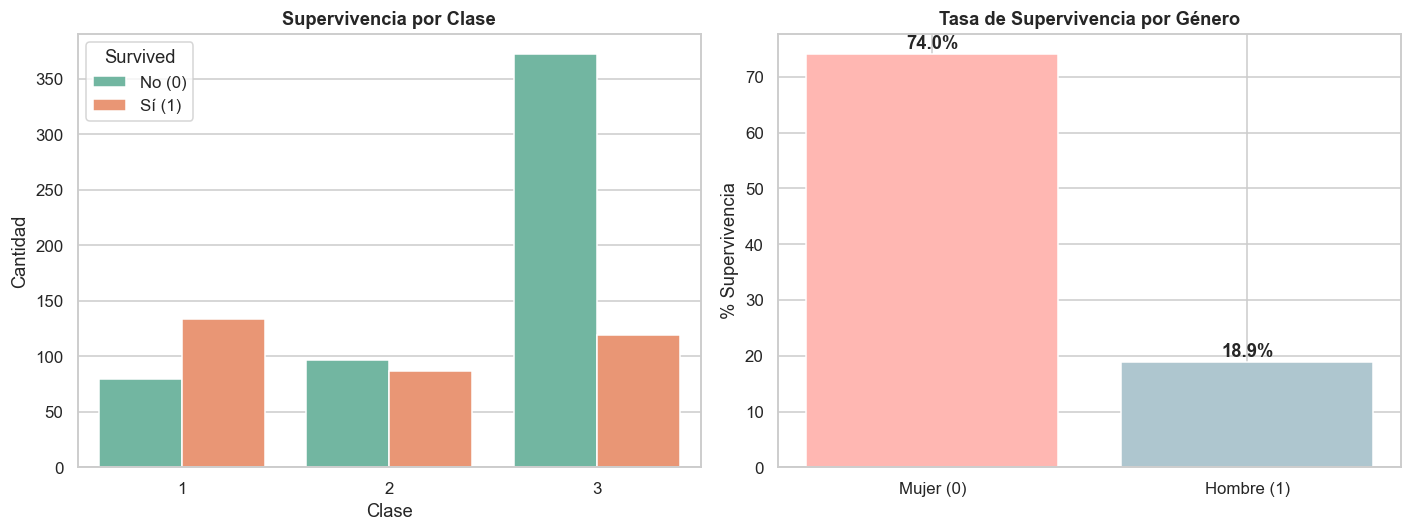

In [39]:
# Supervivencia por Clase y por Género
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(data=df_train, x='Pclass', hue='Survived', ax=axes[0], palette='Set2')
axes[0].set_title('Supervivencia por Clase', fontweight='bold')
axes[0].set_xlabel('Clase'); axes[0].set_ylabel('Cantidad')
axes[0].legend(title='Survived', labels=['No (0)','Sí (1)'])

tasa_sex = df_train.groupby('Sex')['Survived'].mean() * 100
axes[1].bar(['Mujer (0)', 'Hombre (1)'], tasa_sex.values,
            color=['#ffb7b2','#aec6cf'], edgecolor='white')
axes[1].set_title('Tasa de Supervivencia por Género', fontweight='bold')
axes[1].set_ylabel('% Supervivencia')
for i, v in enumerate(tasa_sex.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Interpretación

Se observa que la supervivencia de los pasajeros estuvo fuertemente relacionada con la clase en la que viajaban. La mayoría de los pasajeros que sobrevivieron pertenecían a la primera clase, mientras que la mayor proporción de fallecidos se concentró en la tercera clase, lo que sugiere que la posición socioeconómica y la ubicación dentro del barco influyeron en las probabilidades de supervivencia.

Por otra parte, el género presentó una marcada diferencia en las tasas de supervivencia. Las mujeres registraron una tasa de supervivencia del 74 %, mientras que los hombres alcanzaron únicamente el 18,9 %. Este comportamiento puede explicarse por la política de evacuación aplicada durante el desastre, en la cual se priorizó el rescate de mujeres y niños antes que el de los hombres.

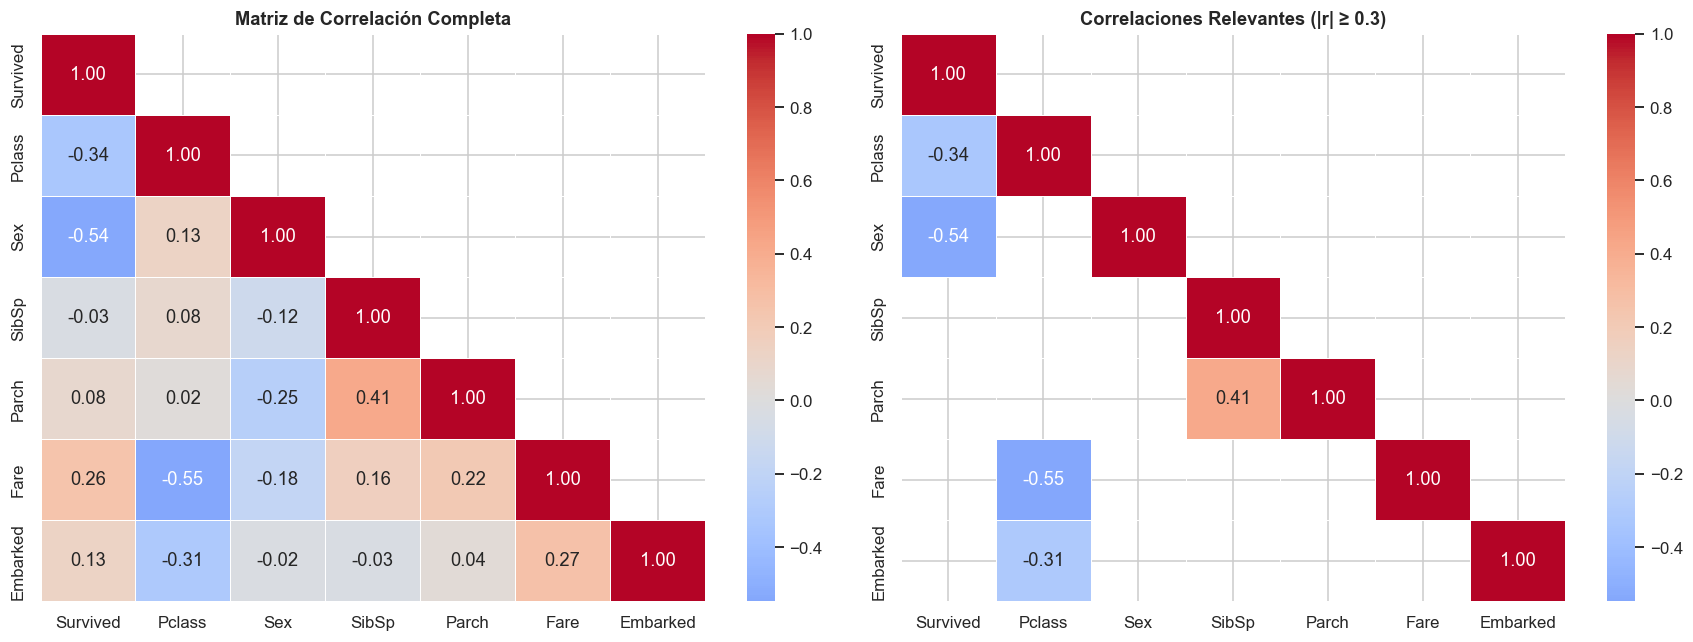


Correlaciones con Survived (ranking):
Sex        -0.5416
Pclass     -0.3355
Fare        0.2553
Embarked    0.1268
Parch       0.0832
SibSp      -0.0340


In [40]:
# Matriz de correlación
num_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
corr = df_train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=.5, ax=axes[0], center=0)
axes[0].set_title('Matriz de Correlación Completa', fontweight='bold')

corr_f = corr.copy()
corr_f[np.abs(corr_f) < 0.3] = np.nan
sns.heatmap(corr_f, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=.5, ax=axes[1], center=0)
axes[1].set_title('Correlaciones Relevantes (|r| ≥ 0.3)', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelaciones con Survived (ranking):')
print(corr['Survived'].drop('Survived').sort_values(key=abs, ascending=False).round(4).to_string())

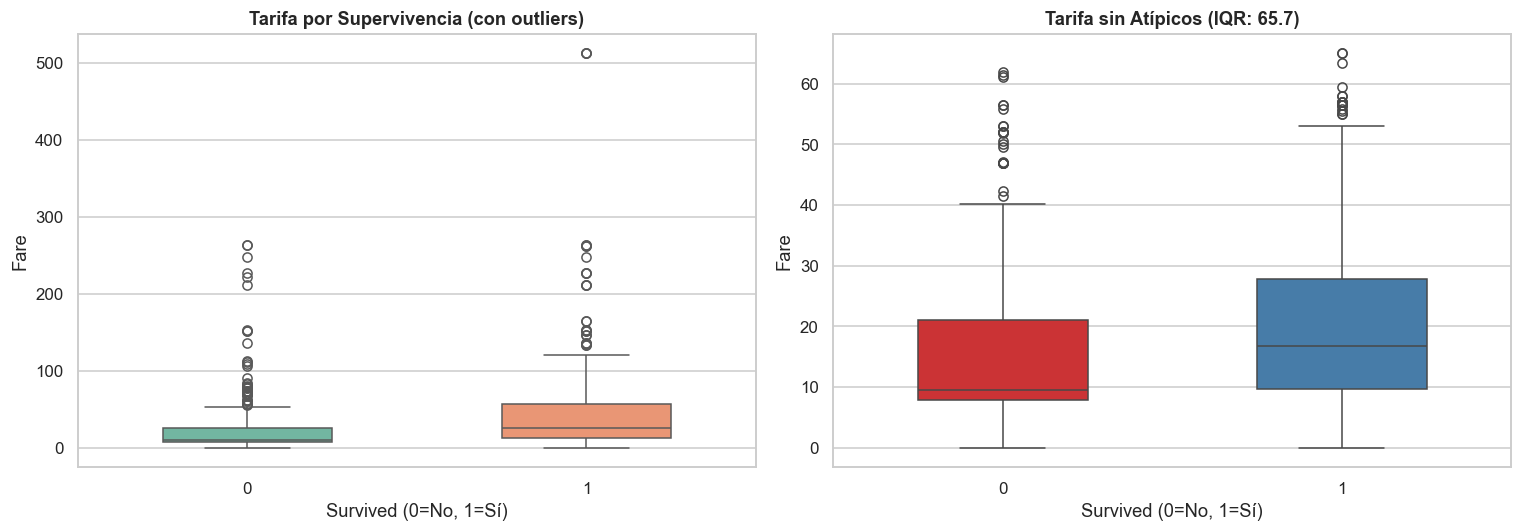

Outliers en Fare: 114 filas


In [41]:
# Boxplot de Fare por Supervivencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_train, x='Survived', y='Fare', ax=axes[0], palette='Set2', width=0.5)
axes[0].set_title('Tarifa por Supervivencia (con outliers)', fontweight='bold')
axes[0].set_xlabel('Survived (0=No, 1=Sí)')

Q1, Q3 = df_train['Fare'].quantile(0.25), df_train['Fare'].quantile(0.75)
IQR = Q3 - Q1
df_clean_fare = df_train[(df_train['Fare'] >= Q1 - 1.5*IQR) & (df_train['Fare'] <= Q3 + 1.5*IQR)]

sns.boxplot(data=df_clean_fare, x='Survived', y='Fare', ax=axes[1], palette='Set1', width=0.5)
axes[1].set_title(f'Tarifa sin Atípicos (IQR: {Q3+1.5*IQR:.1f})', fontweight='bold')
axes[1].set_xlabel('Survived (0=No, 1=Sí)')
plt.tight_layout()
plt.show()
print(f'Outliers en Fare: {len(df_train) - len(df_clean_fare)} filas')

## Interpretación 

La tarifa pagada muestra diferencias claras entre supervivientes y no supervivientes. Los pasajeros que sobrevivieron presentaron tarifas medias notablemente más elevadas, lo que es consistente con que la primera clase tuvo tasas de supervivencia más altas. La versión sin atípicos (filtro IQR) confirma este patrón al eliminar el ruido de tarifas extremas (principalmente suites de primera clase), mostrando que la diferencia de medianas entre grupos se mantiene. Esto refuerza que Fare actúa como proxy de clase socioeconómica y tiene poder discriminativo relevante, consistente con la correlación observada en la matriz de correlación.

### Interpretación del EDA

| Variable | Observación clave | Relevancia predictiva |
|---|---|---|
| `Sex` | Mujeres ~74% supervivencia vs hombres ~19% | **Muy alta** |
| `Pclass` | 1ª clase ~63% vs 3ª clase ~24% | **Alta** |
| `Fare` | Sobrevivientes pagaron tarifas más altas | **Alta** |
| `Age (cat.)` | Niños (0–8) mayor supervivencia | **Moderada** |
| `SibSp`/`Parch` | Familias medianas sobrevivieron más | **Moderada** |
| `Embarked` | Puerto C (Cherbourg) con mayor tasa | **Baja** |

> **Ingeniería de variables:** `family_size = SibSp + Parch + 1` e `is_alone` capturan mejor el efecto familiar.

## 1.8 Ingeniería de Variables y División Train/Test

In [42]:
# Convertir Age de Categorical a int
df_model = df_train.copy()
df_model['Age'] = df_model['Age'].astype(str).astype(int)

# Ingeniería de variables
df_model['family_size'] = df_model['SibSp'] + df_model['Parch'] + 1
df_model['is_alone']    = (df_model['family_size'] == 1).astype(int)

FEATURES_BASE = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
FEATURES_MEJR = FEATURES_BASE + ['family_size', 'is_alone']

X = df_model[FEATURES_MEJR]
y = df_model['Survived']

print('Features:', FEATURES_MEJR)
print(f'\nCorrelación con Survived:')
print(df_model[FEATURES_MEJR + ['Survived']].corr()['Survived'].drop('Survived').round(4).to_string())
print(f'\nDimensiones X: {X.shape}  |  y: {y.shape}')

Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'family_size', 'is_alone']

Correlación con Survived:
Pclass        -0.3355
Sex           -0.5416
Age           -0.1150
SibSp         -0.0340
Parch          0.0832
Fare           0.2553
Embarked       0.1268
family_size    0.0183
is_alone      -0.2062

Dimensiones X: (889, 9)  |  y: (889,)


In [43]:
# División estratificada 80/20
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

# StandardScaler — para SVM y RNA (DT y RF no requieren escalado, pero no lo perjudica)
scaler_std = StandardScaler()
X_tr_std   = scaler_std.fit_transform(X_tr)
X_te_std   = scaler_std.transform(X_te)

# MinMaxScaler — para RNA (siguiendo ejemplo del profesor)
scaler_mm = MinMaxScaler(feature_range=(0, 1))
X_tr_mm   = scaler_mm.fit_transform(X_tr)
X_te_mm   = scaler_mm.transform(X_te)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f'Train: {len(y_tr)} muestras  |  Test: {len(y_te)} muestras')
print(f'Train — 0: {(y_tr==0).sum()}  1: {(y_tr==1).sum()}')
print(f'Test  — 0: {(y_te==0).sum()}  1: {(y_te==1).sum()}')

Train: 711 muestras  |  Test: 178 muestras
Train — 0: 439  1: 272
Test  — 0: 110  1: 68


## 1.9 Función de Evaluación

Función reutilizable para todos los modelos sklearn:

| Métrica | Interpretación |
|---|---|
| **CV Accuracy** | Estimación honesta del rendimiento (5-fold) |
| **Precision** | De los predichos supervivientes, ¿cuántos lo son realmente? |
| **Recall** | De los supervivientes reales, ¿cuántos detectó? |
| **Especificidad** | Recall de la clase negativa |
| **F1-Score** | Media armónica Precision-Recall |
| **AUC-ROC** | Capacidad discriminativa global |
| **R²** | Coeficiente de determinación |

In [44]:
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te, cv_obj, proba=True):
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv_obj, scoring='accuracy')
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)

    if proba and hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_te)[:, 1]
    elif hasattr(modelo, 'decision_function'):
        y_proba = modelo.decision_function(X_te)
    else:
        y_proba = y_pred.astype(float)

    acc_tr = accuracy_score(y_tr, modelo.predict(X_tr))
    acc_te = accuracy_score(y_te, y_pred)
    cm     = confusion_matrix(y_te, y_pred)
    TN, FP, FN, TP = cm.ravel()

    prec  = precision_score(y_te, y_pred, zero_division=0)
    rec   = recall_score(y_te, y_pred)
    f1    = f1_score(y_te, y_pred)
    spec  = TN / (TN + FP)
    auc   = roc_auc_score(y_te, y_proba)
    r2    = r2_score(y_te, y_pred)
    gap   = acc_tr - acc_te

    print(f'\n{"="*56}')
    print(f'  {nombre}')
    print(f'{"="*56}')
    print(f'  CV Accuracy (5-fold) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'  Train Accuracy       : {acc_tr:.4f}')
    print(f'  Test  Accuracy       : {acc_te:.4f}  (gap={gap:+.4f})')
    print(f'  TP={TP}  TN={TN}  FP={FP}  FN={FN}')
    print(f'  Precision    : {prec:.4f}')
    print(f'  Recall       : {rec:.4f}')
    print(f'  Especificidad: {spec:.4f}')
    print(f'  F1-Score     : {f1:.4f}')
    print(f'  AUC-ROC      : {auc:.4f}')
    print(f'  R²           : {r2:.4f}')
    print(f'\n{classification_report(y_te, y_pred, target_names=["No Survived","Survived"])}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No Surv','Surv'], yticklabels=['No Surv','Surv'])
    axes[0].set_title(f'Matriz de Confusión\n{nombre}', fontweight='bold')
    axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC={auc:.3f})')
    axes[1].plot([0,1],[0,1],'navy', lw=1.5, linestyle='--')
    axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Curva ROC\n{nombre}', fontweight='bold')
    axes[1].legend(loc='lower right')
    plt.tight_layout(); plt.show()

    return {
        'Modelo': nombre,
        'CV Acc%': round(cv_scores.mean()*100, 2),
        'Train%' : round(acc_tr*100, 2),
        'Test%'  : round(acc_te*100, 2),
        'Prec%'  : round(prec*100, 2),
        'Recall%': round(rec*100, 2),
        'Espec%' : round(spec*100, 2),
        'F1%'    : round(f1*100, 2),
        'AUC%'   : round(auc*100, 2),
        'R2'     : round(r2, 4),
        'TP':TP, 'TN':TN, 'FP':FP, 'FN':FN,
        '_modelo': modelo, '_X_te': X_te, '_y_te': y_te, '_y_proba': y_proba
    }

print('Función de evaluación definida correctamente.')

Función de evaluación definida correctamente.


---
## 1.10 Árbol de Decisión (Decision Tree)

El Árbol de Decisión aprende reglas de clasificación tipo `IF-THEN` dividiendo el espacio de features de forma recursiva. Es el modelo más **interpretable** de los cuatro.

**Criterios de división:**
- **Gini:** mide impureza del nodo → $Gini = 1 - \sum_k p_k^2$
- **Entropy:** mide desorden de información → $H = -\sum_k p_k \log_2 p_k$

**Hiperparámetros clave:**

| Hiperparámetro | Efecto |
|---|---|
| `max_depth` | Profundidad máxima del árbol. Profundidad alta → sobreajuste |
| `criterion` | Función de impureza: `gini` o `entropy` |
| `min_samples_split` | Mínimo de muestras para dividir un nodo |
| `min_samples_leaf` | Mínimo de muestras en una hoja |

### GridSearchCV — Árbol de Decisión

Mejores hiperparámetros (DT): {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2}
Mejor CV Accuracy: 0.8341


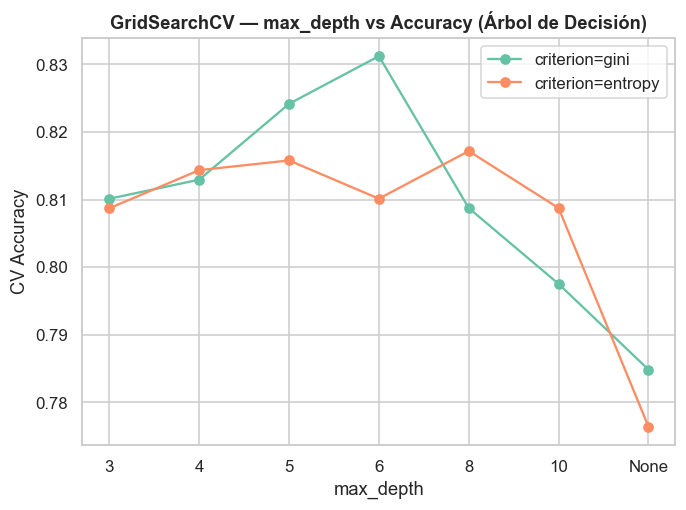

In [45]:
param_grid_dt = {
    'max_depth'        : [3, 4, 5, 6, 8, 10, None],
    'criterion'        : ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=SEED), param_grid_dt,
                     cv=cv, scoring='accuracy', n_jobs=-1)
gs_dt.fit(X_tr, y_tr)

print('Mejores hiperparámetros (DT):', gs_dt.best_params_)
print(f'Mejor CV Accuracy: {gs_dt.best_score_:.4f}')

# Curva max_depth vs Accuracy (gini, min_samples_split=2, min_samples_leaf=1)
results_dt = pd.DataFrame(gs_dt.cv_results_)
for crit in ['gini', 'entropy']:
    mask = ((results_dt['param_criterion'] == crit) &
            (results_dt['param_min_samples_split'] == 2) &
            (results_dt['param_min_samples_leaf'] == 1))
    depths = results_dt[mask]['param_max_depth'].values
    scores = results_dt[mask]['mean_test_score'].values
    order  = np.argsort([d if d is not None else 99 for d in depths])
    plt.plot([str(d) for d in depths[order]], scores[order], marker='o', label=f'criterion={crit}')

plt.xlabel('max_depth')
plt.ylabel('CV Accuracy')
plt.title('GridSearchCV — max_depth vs Accuracy (Árbol de Decisión)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Árbol de Decisión — Versión Baseline


  DT — Baseline (max_depth=4, gini)
  CV Accuracy (5-fold) : 0.8129 ± 0.0221
  Train Accuracy       : 0.8340
  Test  Accuracy       : 0.8090  (gap=+0.0250)
  TP=45  TN=99  FP=11  FN=23
  Precision    : 0.8036
  Recall       : 0.6618
  Especificidad: 0.9000
  F1-Score     : 0.7258
  AUC-ROC      : 0.8468
  R²           : 0.1909

              precision    recall  f1-score   support

 No Survived       0.81      0.90      0.85       110
    Survived       0.80      0.66      0.73        68

    accuracy                           0.81       178
   macro avg       0.81      0.78      0.79       178
weighted avg       0.81      0.81      0.80       178



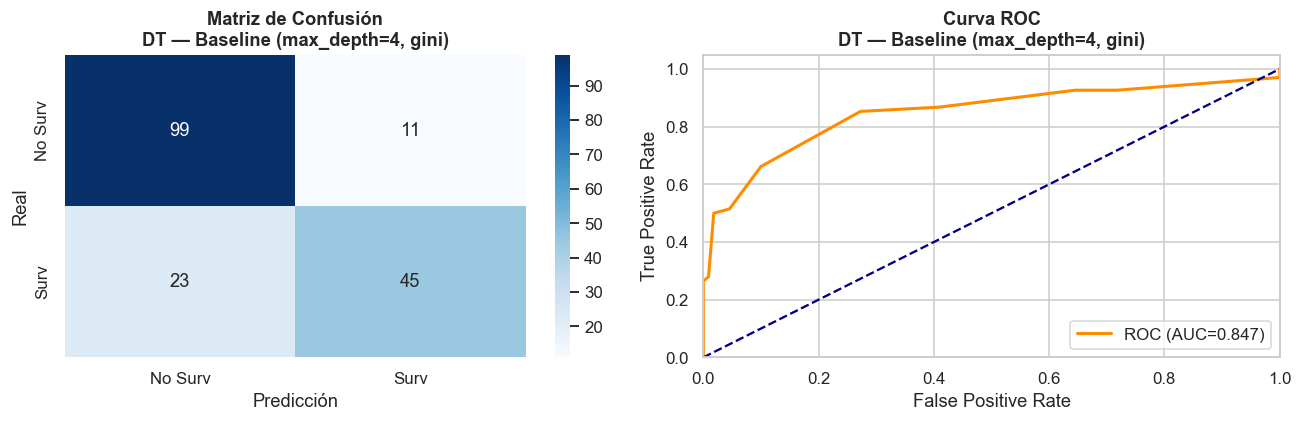

In [46]:
dt_base = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=SEED)
res_dt_base = evaluar_modelo('DT — Baseline (max_depth=4, gini)',
                             dt_base, X_tr, y_tr, X_te, y_te, cv)

### Árbol de Decisión — Versión Mejorada (GridSearchCV)


  DT — Mejorado ({'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2})
  CV Accuracy (5-fold) : 0.8341 ± 0.0226
  Train Accuracy       : 0.8678
  Test  Accuracy       : 0.7865  (gap=+0.0813)
  TP=43  TN=97  FP=13  FN=25
  Precision    : 0.7679
  Recall       : 0.6324
  Especificidad: 0.8818
  F1-Score     : 0.6935
  AUC-ROC      : 0.8257
  R²           : 0.0957

              precision    recall  f1-score   support

 No Survived       0.80      0.88      0.84       110
    Survived       0.77      0.63      0.69        68

    accuracy                           0.79       178
   macro avg       0.78      0.76      0.76       178
weighted avg       0.78      0.79      0.78       178



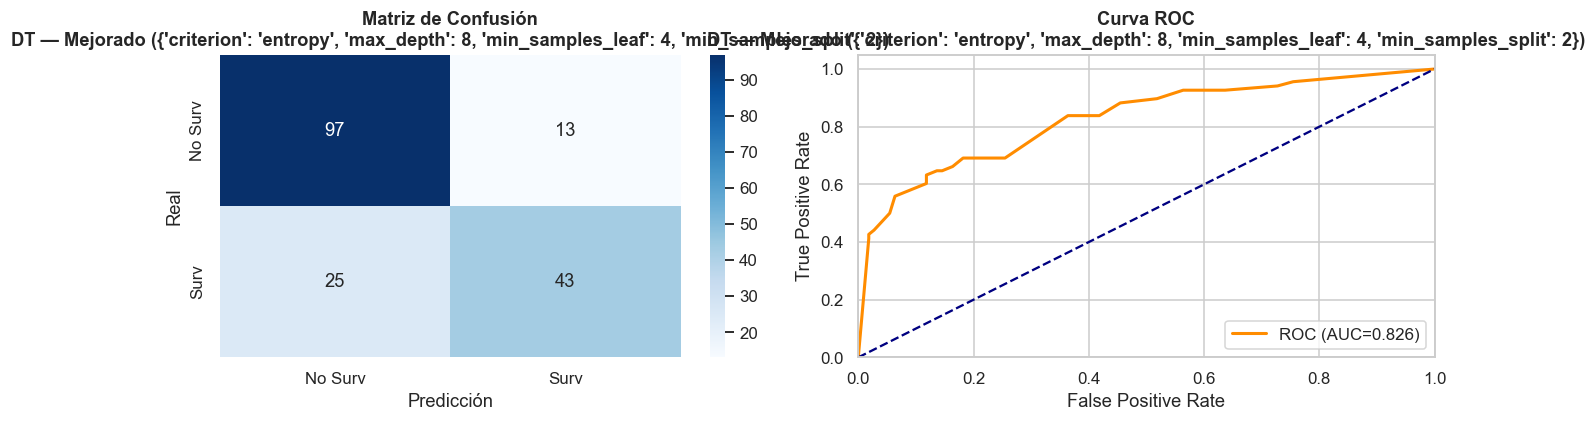

In [47]:
best_dt = gs_dt.best_estimator_
res_dt_mejr = evaluar_modelo(
    f"DT — Mejorado ({gs_dt.best_params_})",
    best_dt, X_tr, y_tr, X_te, y_te, cv
)

### Visualización del Árbol de Decisión

> El enunciado pide explícitamente mostrar el árbol generado. Se visualiza la versión mejorada (con `max_depth` óptimo). Los nodos coloreados indican la clase mayoritaria: **naranja** = No sobrevivió (0), **verde** = Sobrevivió (1).

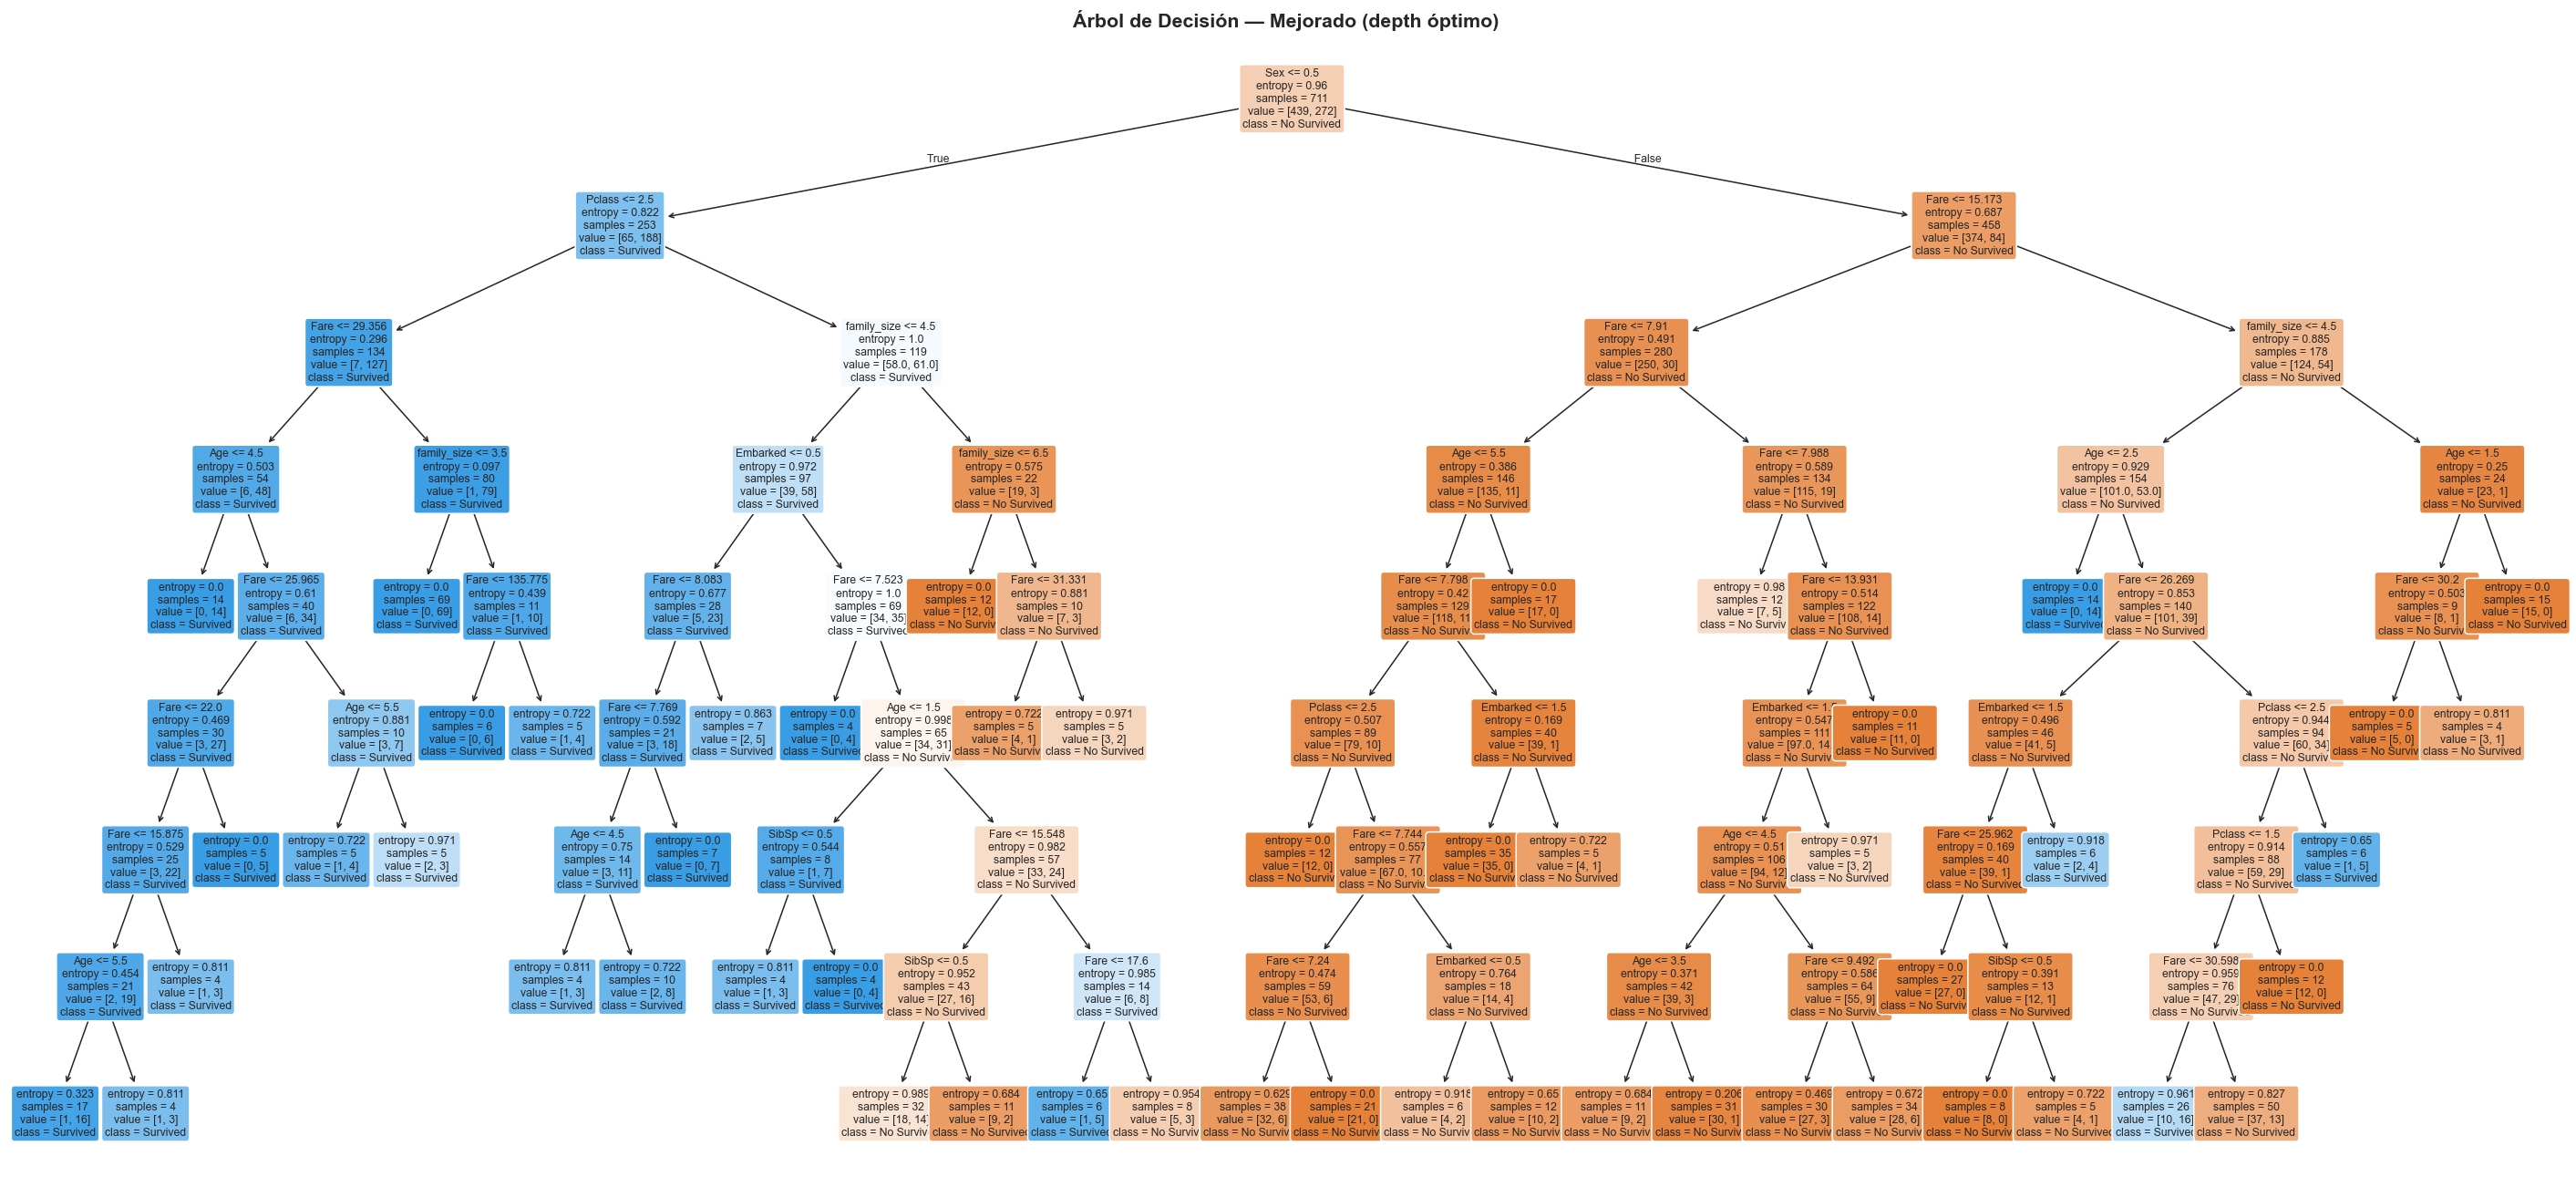

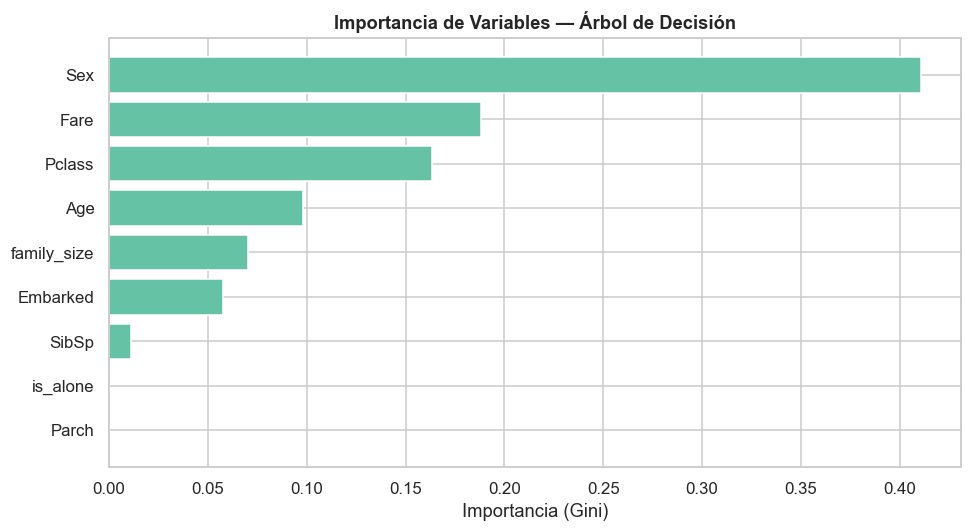

   Variable  Importancia
        Sex     0.410685
       Fare     0.188438
     Pclass     0.163582
        Age     0.098312
family_size     0.070325
   Embarked     0.057428
      SibSp     0.011231
      Parch     0.000000
   is_alone     0.000000


In [48]:
# Árbol del modelo mejorado
fig, ax = plt.subplots(figsize=(26, 12))
plot_tree(
    best_dt,
    feature_names = FEATURES_MEJR,
    class_names   = ['No Survived', 'Survived'],
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    ax            = ax
)
plt.title(f'Árbol de Decisión — Mejorado (depth óptimo)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_arbol_decision.png', bbox_inches='tight', dpi=120)
plt.show()

# Importancia de features
fi_dt = pd.DataFrame({
    'Variable'   : FEATURES_MEJR,
    'Importancia': best_dt.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi_dt['Variable'], fi_dt['Importancia'],
        color='#66C2A5', edgecolor='white')
ax.set_title('Importancia de Variables — Árbol de Decisión', fontweight='bold')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()
print(fi_dt.sort_values('Importancia', ascending=False).to_string(index=False))

### Interpretación — Árbol de Decisión

El Árbol de Decisión produce **reglas explícitas** que permiten explicar cada predicción. La variable `Sex` suele aparecer en el nodo raíz (primera división) por ser la más informativa (reduce más la impureza Gini/Entropy). Las ramas superiores del árbol reflejan el conocimiento histórico: las mujeres y los pasajeros de 1ª clase con menor familia tuvieron mayor supervivencia.

**Sobreajuste:** A mayor `max_depth`, el árbol memoriza el conjunto de entrenamiento (Train Acc → 100%) pero generaliza peor. El GridSearchCV encuentra la profundidad que maximiza el CV Accuracy, equilibrando complejidad y generalización.

---
## 1.11 Bosque Aleatorio (Random Forest)

Random Forest es un **ensemble** de N árboles de decisión entrenados en **subconjuntos aleatorios** de datos y features. La predicción final es la votación mayoritaria de todos los árboles.

**Por qué mejora al árbol único:**
- Cada árbol ve una muestra diferente → reduce varianza
- Cada split solo considera un subconjunto de features → reduce correlación entre árboles
- La votación promedia errores individuales

**Hiperparámetros clave:**

| Hiperparámetro | Efecto |
|---|---|
| `n_estimators` | Número de árboles. Más → más estable pero más lento |
| `max_depth` | Profundidad máxima de cada árbol |
| `criterion` | `gini` o `entropy` |
| `max_features` | Fracción de features evaluadas en cada split (`sqrt`, `log2`) |

### GridSearchCV — Bosque Aleatorio

Mejores hiperparámetros (RF): {'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 200}
Mejor CV Accuracy: 0.8327


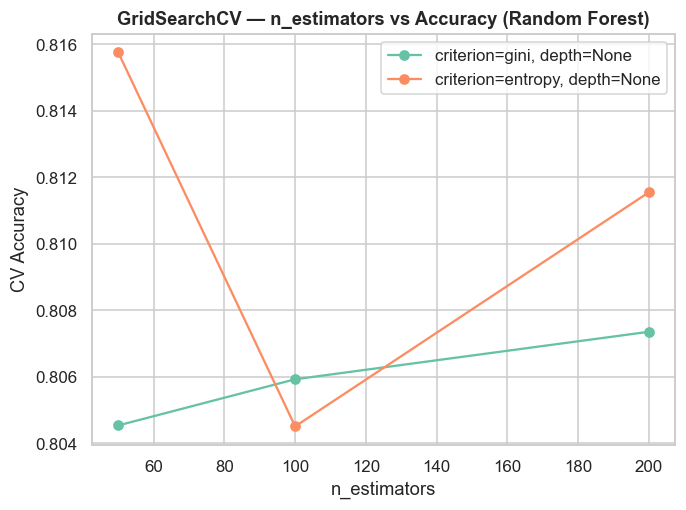

In [49]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [4, 6, 8, None],
    'criterion'   : ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2']
}

gs_rf = GridSearchCV(RandomForestClassifier(random_state=SEED), param_grid_rf,
                     cv=cv, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_tr, y_tr)

print('Mejores hiperparámetros (RF):', gs_rf.best_params_)
print(f'Mejor CV Accuracy: {gs_rf.best_score_:.4f}')

# Curva n_estimators vs Accuracy
results_rf = pd.DataFrame(gs_rf.cv_results_)
for crit in ['gini', 'entropy']:
    mask = ((results_rf['param_criterion'] == crit) &
            (results_rf['param_max_depth'].isna()) &
            (results_rf['param_max_features'] == 'sqrt'))
    if mask.sum() > 0:
        plt.plot(param_grid_rf['n_estimators'],
                 results_rf[mask]['mean_test_score'].values,
                 marker='o', label=f'criterion={crit}, depth=None')

plt.xlabel('n_estimators')
plt.ylabel('CV Accuracy')
plt.title('GridSearchCV — n_estimators vs Accuracy (Random Forest)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Bosque Aleatorio — Versión Baseline


  RF — Baseline (n=10, depth=4, entropy)
  CV Accuracy (5-fold) : 0.8185 ± 0.0263
  Train Accuracy       : 0.8397
  Test  Accuracy       : 0.8202  (gap=+0.0194)
  TP=45  TN=101  FP=9  FN=23
  Precision    : 0.8333
  Recall       : 0.6618
  Especificidad: 0.9182
  F1-Score     : 0.7377
  AUC-ROC      : 0.8505
  R²           : 0.2385

              precision    recall  f1-score   support

 No Survived       0.81      0.92      0.86       110
    Survived       0.83      0.66      0.74        68

    accuracy                           0.82       178
   macro avg       0.82      0.79      0.80       178
weighted avg       0.82      0.82      0.82       178



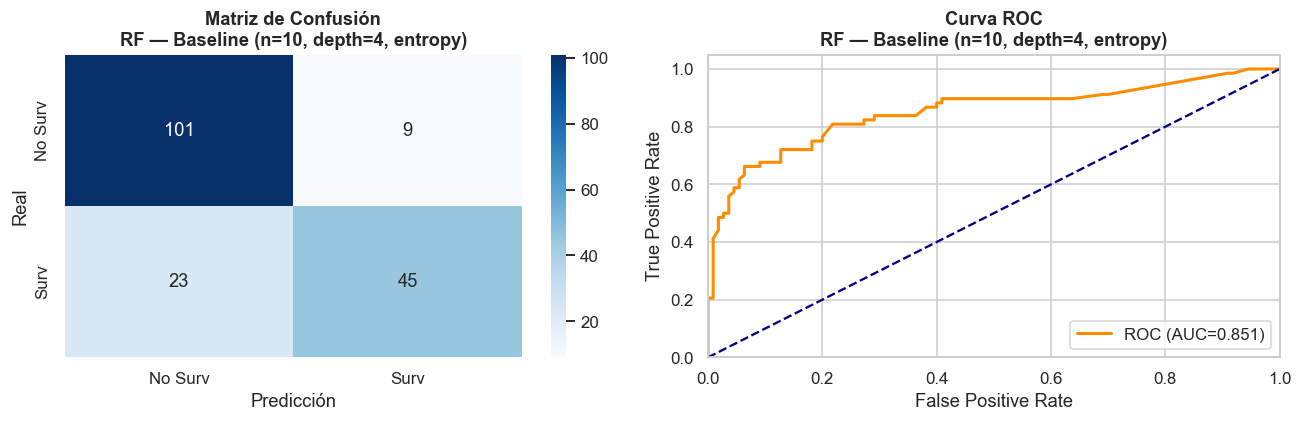

In [50]:
rf_base = RandomForestClassifier(n_estimators=10, max_depth=4,
                                  criterion='entropy', random_state=SEED)
res_rf_base = evaluar_modelo('RF — Baseline (n=10, depth=4, entropy)',
                             rf_base, X_tr, y_tr, X_te, y_te, cv)

### Bosque Aleatorio — Versión Mejorada (GridSearchCV)


  RF — Mejorado ({'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 200})
  CV Accuracy (5-fold) : 0.8327 ± 0.0285
  Train Accuracy       : 0.9212
  Test  Accuracy       : 0.8090  (gap=+0.1122)
  TP=47  TN=97  FP=13  FN=21
  Precision    : 0.7833
  Recall       : 0.6912
  Especificidad: 0.8818
  F1-Score     : 0.7344
  AUC-ROC      : 0.8460
  R²           : 0.1909

              precision    recall  f1-score   support

 No Survived       0.82      0.88      0.85       110
    Survived       0.78      0.69      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.79      0.79       178
weighted avg       0.81      0.81      0.81       178



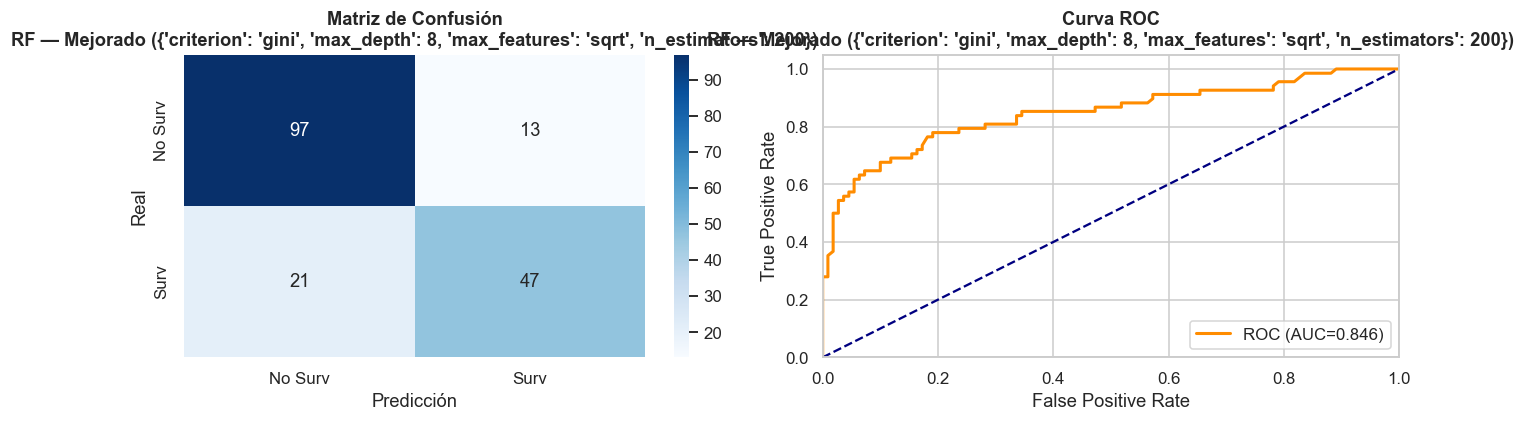

In [51]:
best_rf = gs_rf.best_estimator_
res_rf_mejr = evaluar_modelo(
    f"RF — Mejorado ({gs_rf.best_params_})",
    best_rf, X_tr, y_tr, X_te, y_te, cv
)

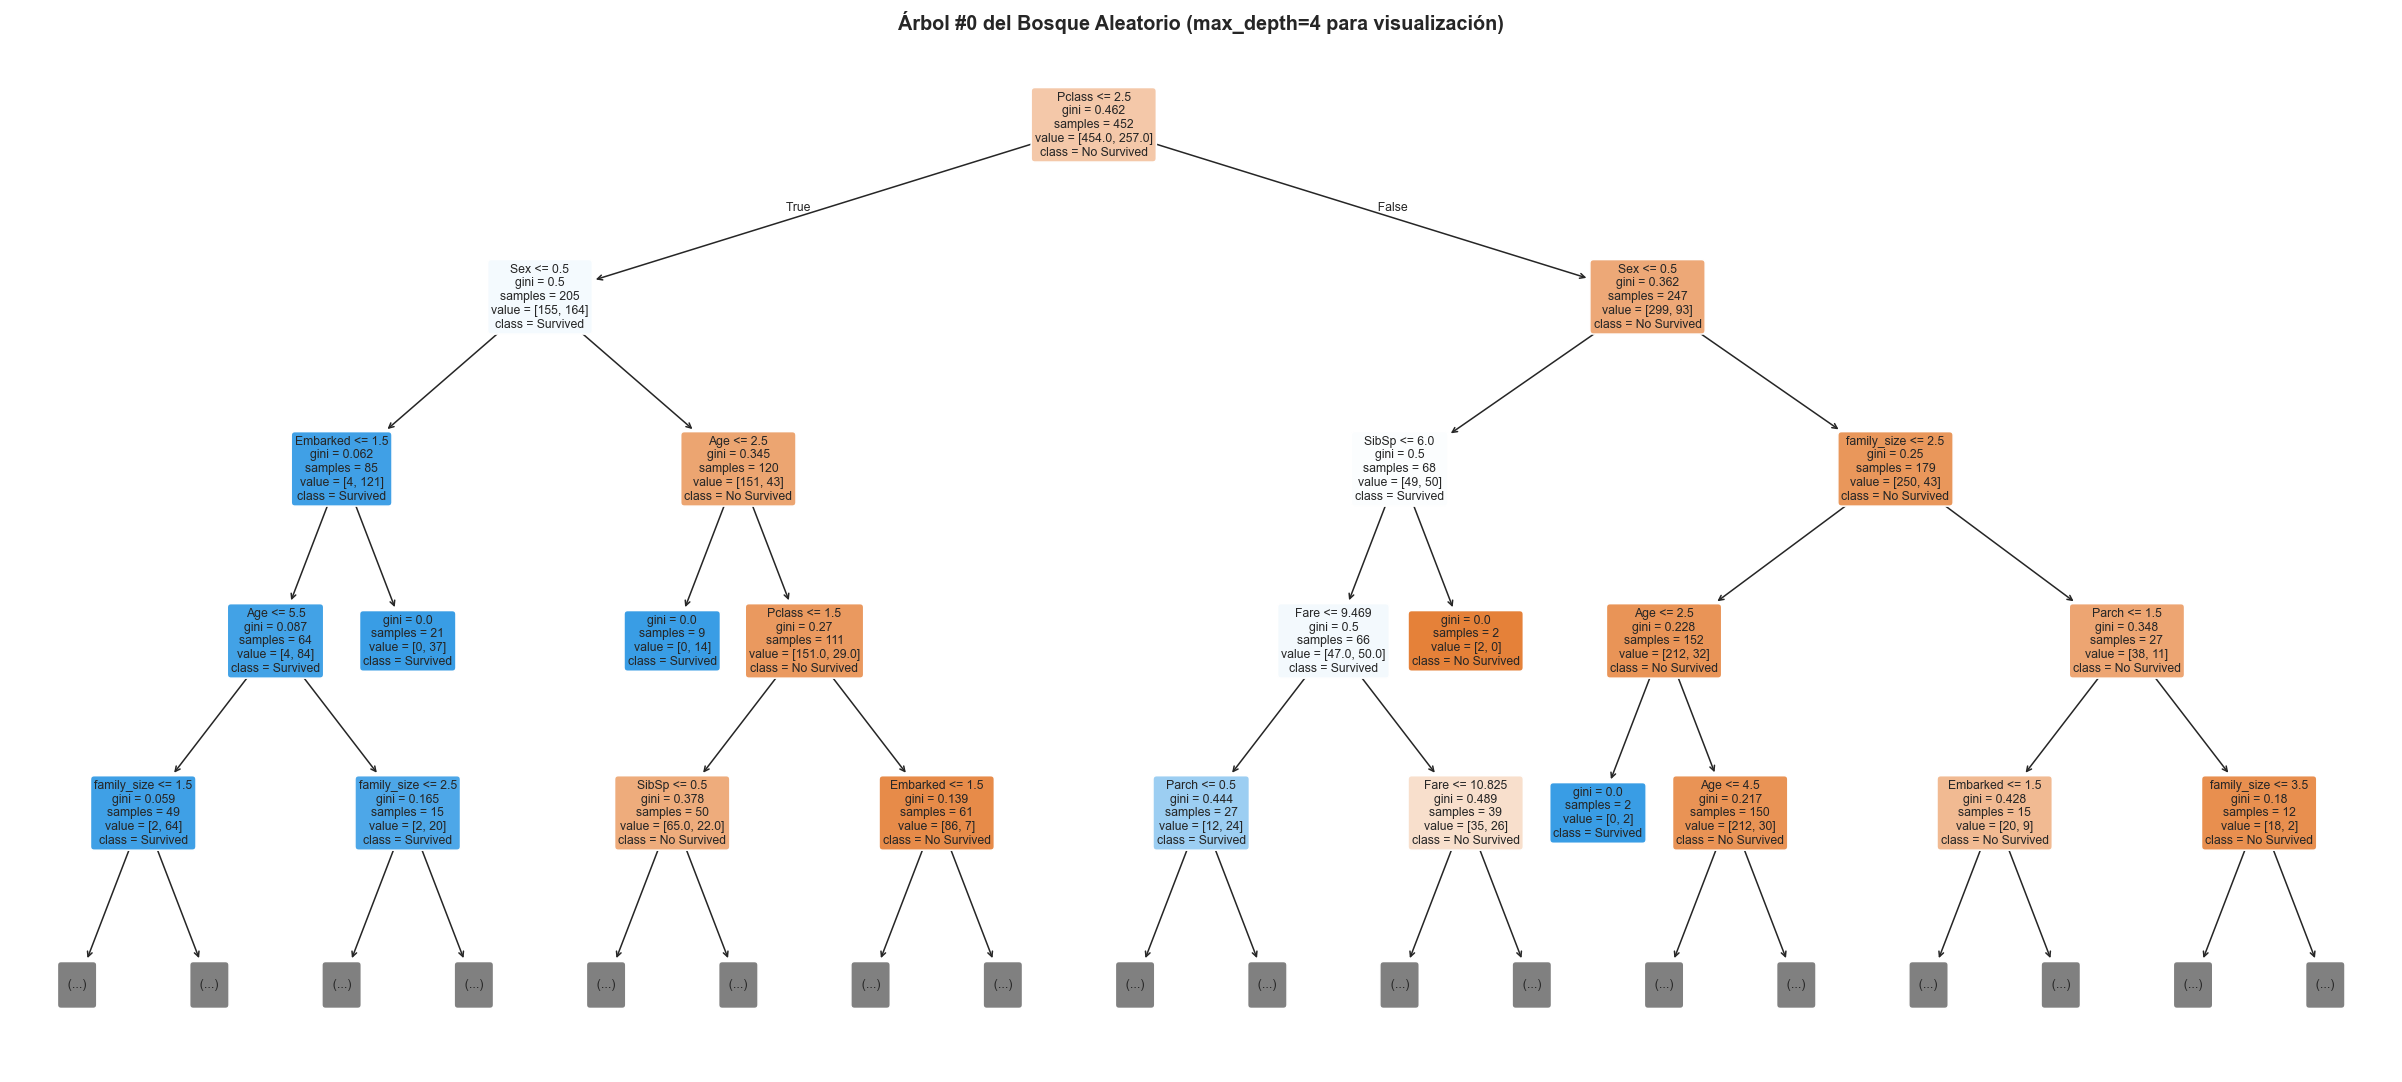

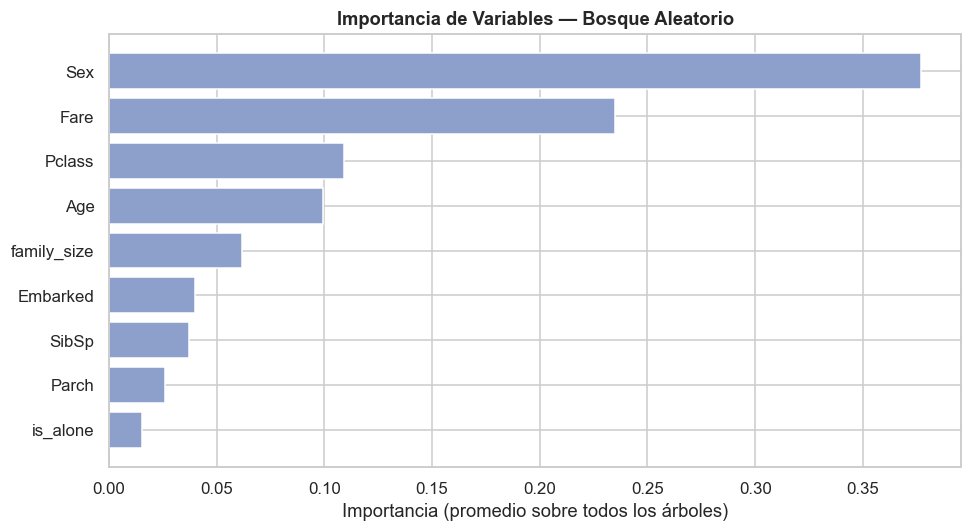

In [52]:
# Árbol del primer estimador del bosque
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    best_rf.estimators_[0],
    feature_names = FEATURES_MEJR,
    class_names   = ['No Survived', 'Survived'],
    filled        = True,
    rounded       = True,
    fontsize      = 8,
    max_depth     = 4,
    ax            = ax
)
plt.title('Árbol #0 del Bosque Aleatorio (max_depth=4 para visualización)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_rf_arbol0.png', bbox_inches='tight', dpi=100)
plt.show()

# Importancia de features RF
fi_rf = pd.DataFrame({
    'Variable'   : FEATURES_MEJR,
    'Importancia': best_rf.feature_importances_
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi_rf['Variable'], fi_rf['Importancia'], color='#8DA0CB', edgecolor='white')
ax.set_title('Importancia de Variables — Bosque Aleatorio', fontweight='bold')
ax.set_xlabel('Importancia (promedio sobre todos los árboles)')
plt.tight_layout()
plt.show()

### Interpretación — Bosque Aleatorio

Random Forest supera al árbol único porque promedia el ruido de cada árbol individual. La importancia de features en RF es más confiable que en un árbol único, ya que se promedia sobre todos los árboles y subconjuntos de datos.

**Diferencia con el Árbol único:** El árbol único puede sesgarse hacia la feature más dominante en la raíz. El bosque, al probar diferentes subconjuntos de features en cada nodo de cada árbol, da una estimación de importancia más equilibrada y robusta.

En general, el modelo de Bosques Aleatorios identifica al género, la tarifa del boleto y la clase del pasajero como las variables más influyentes para predecir la supervivencia, lo que evidencia que las condiciones de evacuación y la posición socioeconómica de los pasajeros fueron factores determinantes durante el desastre del Titanic.

---
## 1.12 Máquina de Vectores de Soporte (SVM)

SVM busca el **hiperplano de margen máximo** que separa las dos clases. Los puntos más cercanos al hiperplano se llaman **vectores de soporte** y son los únicos que determinan la frontera de decisión.

**Kernel Trick:** Cuando los datos no son linealmente separables, SVM los proyecta implícitamente a un espacio de mayor dimensión mediante una función kernel:

| Kernel | Función | Cuándo usar |
|---|---|---|
| `linear` | $K(x,z) = x^T z$ | Datos linealmente separables, alta dimensionalidad |
| `rbf` | $K(x,z) = e^{-\gamma\|x-z\|^2}$ | Fronteras curvas complejas (más común) |
| `poly` | $K(x,z) = (\gamma x^T z + r)^d$ | Relaciones polinomiales |

**Hiperparámetros clave:**

| Hiperparámetro | Efecto |
|---|---|
| `C` | Penalización por error. Alto C → margen estrecho, más ajuste |
| `gamma` | Influencia de cada muestra en `rbf`. Alto gamma → frontera muy local |
| `kernel` | Tipo de transformación del espacio |

> **Importante:** SVM requiere `probability=True` para obtener probabilidades y calcular AUC-ROC.

### GridSearchCV — SVM

Mejores hiperparámetros (SVM): {'C': 0.5, 'gamma': 'auto', 'kernel': 'rbf'}
Mejor CV Accuracy: 0.8270


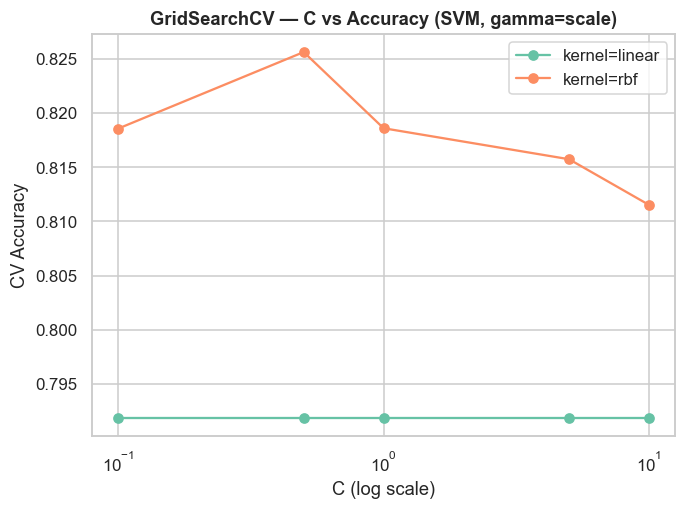

In [53]:
param_grid_svm = {
    'kernel': ['linear', 'rbf'],
    'C'     : [0.1, 0.5, 1.0, 5.0, 10.0],
    'gamma' : ['scale', 'auto']
}

gs_svm = GridSearchCV(SVC(probability=True, random_state=SEED), param_grid_svm,
                      cv=cv, scoring='accuracy', n_jobs=-1)
gs_svm.fit(X_tr_std, y_tr)

print('Mejores hiperparámetros (SVM):', gs_svm.best_params_)
print(f'Mejor CV Accuracy: {gs_svm.best_score_:.4f}')

# Curva C vs Accuracy por kernel
results_svm = pd.DataFrame(gs_svm.cv_results_)
for kernel in ['linear', 'rbf']:
    mask = ((results_svm['param_kernel'] == kernel) &
            (results_svm['param_gamma'] == 'scale'))
    plt.plot(param_grid_svm['C'],
             results_svm[mask]['mean_test_score'].values,
             marker='o', label=f'kernel={kernel}')

plt.xscale('log')
plt.xlabel('C (log scale)')
plt.ylabel('CV Accuracy')
plt.title('GridSearchCV — C vs Accuracy (SVM, gamma=scale)', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## Interpretación

Los resultados muestran que el kernel RBF obtuvo un desempeño superior al kernel lineal para todos los valores evaluados de C. El mayor valor de exactitud en validación cruzada (CV Accuracy = 82,7 %) se alcanzó con los hiperparámetros C=0.5, kernel = RBF y γ=auto, siendo esta la configuración seleccionada como óptima.

Se observa además que, para el kernel RBF, el rendimiento aumenta al pasar de C=0.1 a C=0.5, alcanzando su máximo valor. Sin embargo, al incrementar el parámetro C por encima de este valor, la precisión disminuye gradualmente, lo que sugiere que valores elevados de C pueden reducir la capacidad de generalización del modelo.

Por otra parte, el kernel lineal mantiene una exactitud prácticamente constante cercana al 79,2 % para todos los valores de C, indicando que las relaciones presentes en los datos no pueden ser representadas adecuadamente mediante una frontera de decisión lineal.

En consecuencia, los resultados evidencian que la relación entre las variables predictoras y la supervivencia presenta un comportamiento no lineal, por lo que el kernel RBF resulta más adecuado para modelar este problema de clasificación.

### SVM — Versión Baseline


  SVM — Baseline (linear, C=1.0)
  CV Accuracy (5-fold) : 0.7919 ± 0.0370
  Train Accuracy       : 0.7932
  Test  Accuracy       : 0.7809  (gap=+0.0124)
  TP=43  TN=96  FP=14  FN=25
  Precision    : 0.7544
  Recall       : 0.6324
  Especificidad: 0.8727
  F1-Score     : 0.6880
  AUC-ROC      : 0.8251
  R²           : 0.0719

              precision    recall  f1-score   support

 No Survived       0.79      0.87      0.83       110
    Survived       0.75      0.63      0.69        68

    accuracy                           0.78       178
   macro avg       0.77      0.75      0.76       178
weighted avg       0.78      0.78      0.78       178



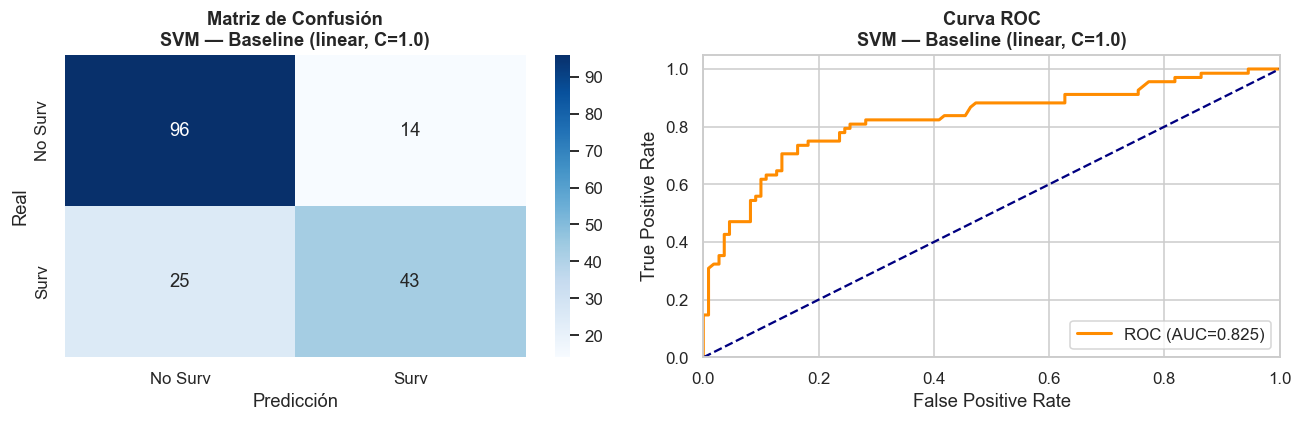

In [54]:
svm_base = SVC(kernel='linear', C=1.0, gamma='scale', probability=True, random_state=SEED)
res_svm_base = evaluar_modelo('SVM — Baseline (linear, C=1.0)',
                              svm_base, X_tr_std, y_tr, X_te_std, y_te, cv)

### SVM — Versión Mejorada (GridSearchCV)


  SVM — Mejorado ({'C': 0.5, 'gamma': 'auto', 'kernel': 'rbf'})
  CV Accuracy (5-fold) : 0.8270 ± 0.0301
  Train Accuracy       : 0.8340
  Test  Accuracy       : 0.8090  (gap=+0.0250)
  TP=46  TN=98  FP=12  FN=22
  Precision    : 0.7931
  Recall       : 0.6765
  Especificidad: 0.8909
  F1-Score     : 0.7302
  AUC-ROC      : 0.8251
  R²           : 0.1909

              precision    recall  f1-score   support

 No Survived       0.82      0.89      0.85       110
    Survived       0.79      0.68      0.73        68

    accuracy                           0.81       178
   macro avg       0.80      0.78      0.79       178
weighted avg       0.81      0.81      0.81       178



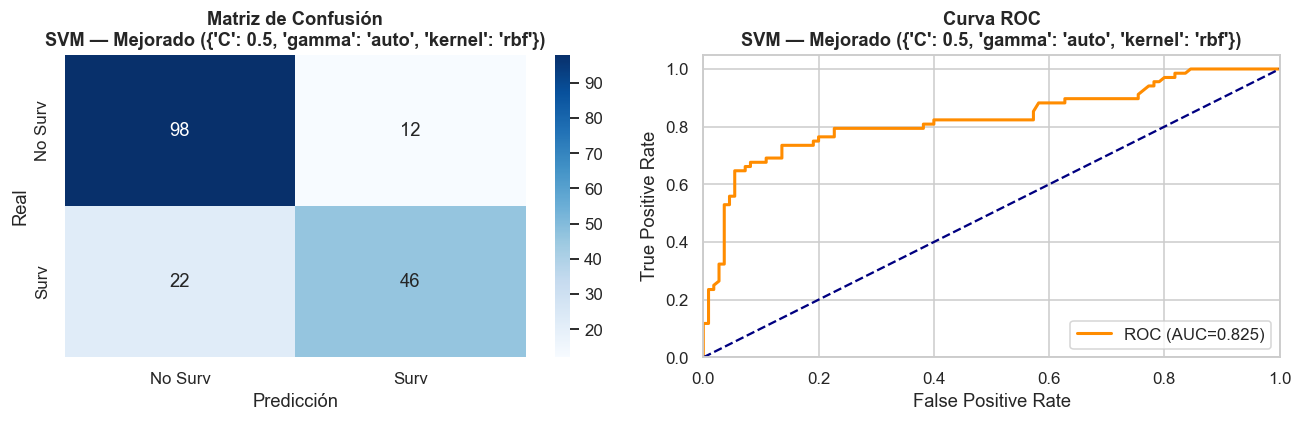

In [55]:
best_svm = gs_svm.best_estimator_
res_svm_mejr = evaluar_modelo(
    f"SVM — Mejorado ({gs_svm.best_params_})",
    best_svm, X_tr_std, y_tr, X_te_std, y_te, cv
)

### Interpretación — SVM

SVM con kernel `rbf` puede modelar fronteras de decisión curvas que los modelos lineales no pueden capturar. En el Titanic, la relación entre `Sex`, `Pclass` y `Fare` no es perfectamente lineal, por lo que `rbf` suele superar a `linear`.

**C y regularización:** Un C alto permite al modelo ajustarse más a los datos de entrenamiento (menos margen, más vectores de soporte). Si el CV Accuracy cae con C muy alto, hay sobreajuste.

## 1.13 Guardado de Modelos — Fase I

In [56]:
SAVE_PATH = r'C:\Users\cabarca2\MAESTRIA_IA\5.  APRENDIZAJE AUTOMATICO ESTADISTICO\SEMANA 2\DEBER AAE'

joblib.dump(best_dt,  f'{SAVE_PATH}\\dt_model_w2.pkl')
joblib.dump(best_rf,  f'{SAVE_PATH}\\rf_model_w2.pkl')
joblib.dump(best_svm, f'{SAVE_PATH}\\svm_model_w2.pkl')
joblib.dump(scaler_std, f'{SAVE_PATH}\\scaler_std_w2.pkl')

print('Modelos Fase I guardados:')
print(f'  dt_model_w2.pkl  → DT  Acc Test: {res_dt_mejr["Test%"]}%')
print(f'  rf_model_w2.pkl  → RF  Acc Test: {res_rf_mejr["Test%"]}%')
print(f'  svm_model_w2.pkl → SVM Acc Test: {res_svm_mejr["Test%"]}%')

Modelos Fase I guardados:
  dt_model_w2.pkl  → DT  Acc Test: 78.65%
  rf_model_w2.pkl  → RF  Acc Test: 80.9%
  svm_model_w2.pkl → SVM Acc Test: 80.9%


---
# Fase II
## 2.1 Red Neuronal Artificial (RNA) — TensorFlow / Keras

Una RNA aprende representaciones jerárquicas de los datos mediante **capas de neuronas interconectadas**. Cada neurona aplica una transformación no lineal a la combinación lineal de sus entradas:

$$a^{(l)} = f\left(W^{(l)} a^{(l-1)} + b^{(l)}\right)$$

**Arquitectura del modelo:**

| Capa | Neuronas | Activación | Descripción |
|---|---|---|---|
| Dense (entrada) | 64 | ReLU | Aprende relaciones lineales + no lineales |
| BatchNorm | — | — | Normaliza activaciones → entrena más estable |
| Dropout (0.3) | — | — | Regularización: desactiva 30% de neuronas aleatoriamente |
| Dense (oculta) | 32 | ReLU | Segunda representación |
| Dropout (0.2) | — | — | Regularización |
| Dense (salida) | 1 | Sigmoid | Probabilidad de supervivencia $P(y=1|x)$ |

**Función de pérdida:** `binary_crossentropy` = $-\frac{1}{N}\sum[y\log\hat{y} + (1-y)\log(1-\hat{y})]$ → equivalente a MLE

**Optimizador:** Adam (Adaptive Moment Estimation) — ajusta automáticamente la tasa de aprendizaje por parámetro

**Callbacks:**
- `EarlyStopping`: detiene el entrenamiento si `val_loss` no mejora en N épocas
- `ReduceLROnPlateau`: reduce la tasa de aprendizaje si el modelo estanca

In [57]:
n_features = X_tr_mm.shape[1]

def build_model(learning_rate=1e-3):
    model = Sequential([
        Dense(64, activation='relu', input_dim=n_features),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        loss      = 'binary_crossentropy',
        optimizer = Adam(learning_rate=learning_rate),
        metrics   = ['accuracy']
    )
    return model

rna = build_model(learning_rate=1e-2)
rna.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 128 (512.00 B)

### 2.2 Entrenamiento con EarlyStopping y ReduceLROnPlateau

In [58]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=7, min_lr=1e-6, verbose=1)
]

history = rna.fit(
    X_tr_mm, y_tr,
    epochs          = 150,
    batch_size      = 32,
    validation_data = (X_te_mm, y_te),
    callbacks       = callbacks,
    verbose         = 1
)

print(f'\nEntrenamiento finalizado en época: {len(history.history["loss"])}')

Epoch 1/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.7314 - loss: 0.5848 - val_accuracy: 0.6180 - val_loss: 0.6037 - learning_rate: 0.0100
Epoch 2/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7947 - loss: 0.4869 - val_accuracy: 0.6180 - val_loss: 0.5848 - learning_rate: 0.0100
Epoch 3/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7904 - loss: 0.4780 - val_accuracy: 0.6180 - val_loss: 0.5840 - learning_rate: 0.0100
Epoch 4/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7975 - loss: 0.4707 - val_accuracy: 0.6180 - val_loss: 0.5757 - learning_rate: 0.0100
Epoch 5/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8087 - loss: 0.4526 - val_accuracy: 0.6124 - val_loss: 0.5805 - learning_rate: 0.0100
Epoch 6/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8172 - loss: 0.4381 - val_accuracy: 0.6798 - val_loss: 0.5670 - learning_rate: 0.0100
Epoch 7/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8059 - loss: 0.4386 - 

### 2.3 Curvas de Aprendizaje (Loss y Accuracy)

> El enunciado solicita explícitamente las **curvas de aprendizaje**. Permiten detectar sobreajuste (train y val divergen) o subajuste (ambas curvas altas en loss).

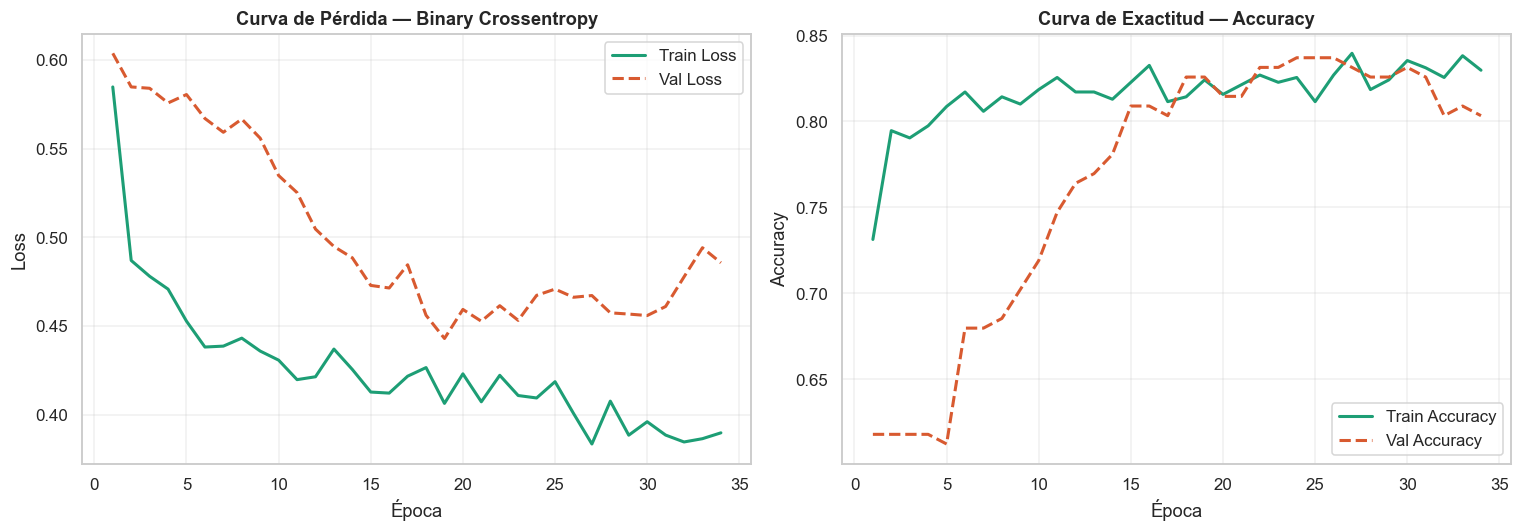

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de pérdida
epochs = range(1, len(history.history['loss']) + 1)
axes[0].plot(epochs, history.history['loss'],     color='#1D9E75', lw=2, label='Train Loss')
axes[0].plot(epochs, history.history['val_loss'], color='#D85A30', lw=2, label='Val Loss', linestyle='--')
axes[0].set_title('Curva de Pérdida — Binary Crossentropy', fontweight='bold')
axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Curva de accuracy
axes[1].plot(epochs, history.history['accuracy'],     color='#1D9E75', lw=2, label='Train Accuracy')
axes[1].plot(epochs, history.history['val_accuracy'], color='#D85A30', lw=2, label='Val Accuracy', linestyle='--')
axes[1].set_title('Curva de Exactitud — Accuracy', fontweight='bold')
axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_rna_curvas.png', bbox_inches='tight')
plt.show()

## Interpretación

En la curva de pérdida, se observa que la pérdida del conjunto de entrenamiento disminuye progresivamente desde aproximadamente 0,58 hasta 0,39, indicando que el modelo aprende adecuadamente los patrones presentes en los datos. De manera similar, la pérdida del conjunto de validación desciende desde valores cercanos a 0,60 hasta alrededor de 0,46, lo que evidencia una mejora en la capacidad de generalización del modelo. En términos generales, el modelo neuronal logra aprender eficazmente los patrones asociados a la supervivencia de los pasajeros, alcanzando una exactitud cercana al 84 % y mostrando únicamente un leve indicio de sobreajuste en las etapas finales del entrenamiento.

### 2.4 Evaluación de la RNA

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
  RNA — Red Neuronal Artificial (TF/Keras)
  Train Accuracy       : 0.8312
  Test  Accuracy       : 0.8258
  TP=42  TN=105  FP=5  FN=26
  Precision    : 0.8936
  Recall       : 0.6176
  Especificidad: 0.9545
  F1-Score     : 0.7304
  AUC-ROC      : 0.8752
  R²           : 0.2623

              precision    recall  f1-score   support

 No Survived       0.80      0.95      0.87       110
    Survived       0.89      0.62      0.73        68

    accuracy                           0.83       178
   macro avg       0.85      0.79      0.80       178
weighted avg       0.84      0.83      0.82       178



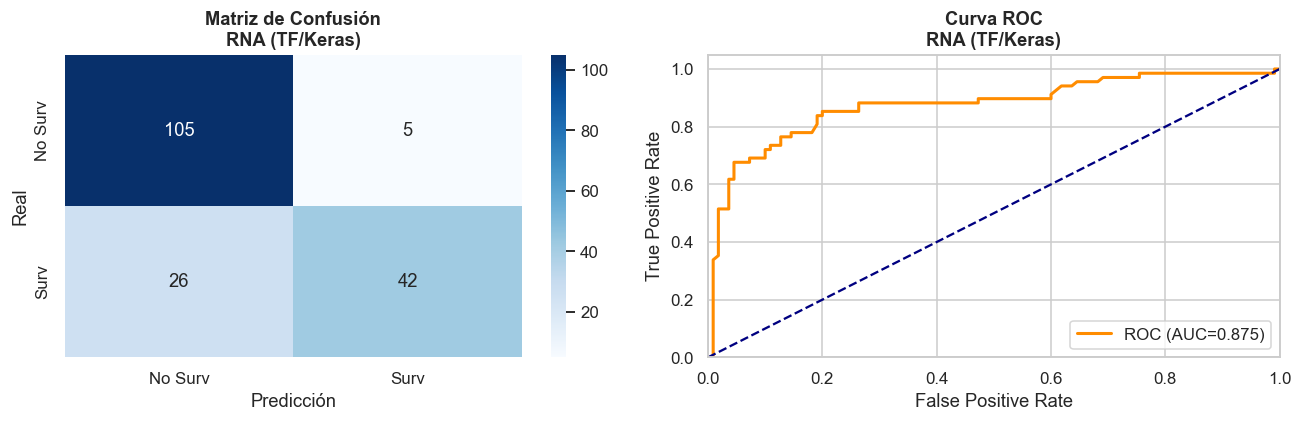

In [60]:
# Predicciones
y_proba_rna = rna.predict(X_te_mm).flatten()
y_pred_rna  = (y_proba_rna > 0.5).astype(int)

# Métricas
acc_tr_rna = (rna.predict(X_tr_mm).flatten() > 0.5).astype(int)
acc_tr_val = accuracy_score(y_tr, acc_tr_rna)
acc_te_rna = accuracy_score(y_te, y_pred_rna)
cm_rna     = confusion_matrix(y_te, y_pred_rna)
TN, FP, FN, TP = cm_rna.ravel()

prec_rna = precision_score(y_te, y_pred_rna, zero_division=0)
rec_rna  = recall_score(y_te, y_pred_rna)
f1_rna   = f1_score(y_te, y_pred_rna)
spec_rna = TN / (TN + FP)
auc_rna  = roc_auc_score(y_te, y_proba_rna)
r2_rna   = r2_score(y_te, y_pred_rna)

print('=' * 56)
print('  RNA — Red Neuronal Artificial (TF/Keras)')
print('=' * 56)
print(f'  Train Accuracy       : {acc_tr_val:.4f}')
print(f'  Test  Accuracy       : {acc_te_rna:.4f}')
print(f'  TP={TP}  TN={TN}  FP={FP}  FN={FN}')
print(f'  Precision    : {prec_rna:.4f}')
print(f'  Recall       : {rec_rna:.4f}')
print(f'  Especificidad: {spec_rna:.4f}')
print(f'  F1-Score     : {f1_rna:.4f}')
print(f'  AUC-ROC      : {auc_rna:.4f}')
print(f'  R²           : {r2_rna:.4f}')
print(f'\n{classification_report(y_te, y_pred_rna, target_names=["No Survived","Survived"])}')

# Matriz de confusión y ROC
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm_rna, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Surv','Surv'], yticklabels=['No Surv','Surv'])
axes[0].set_title('Matriz de Confusión\nRNA (TF/Keras)', fontweight='bold')
axes[0].set_xlabel('Predicción'); axes[0].set_ylabel('Real')
fpr_r, tpr_r, _ = roc_curve(y_te, y_proba_rna)
axes[1].plot(fpr_r, tpr_r, color='darkorange', lw=2, label=f'ROC (AUC={auc_rna:.3f})')
axes[1].plot([0,1],[0,1],'navy', lw=1.5, linestyle='--')
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.05])
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC\nRNA (TF/Keras)', fontweight='bold')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

# Resultado para comparativa
res_rna = {
    'Modelo': 'RNA — TF/Keras',
    'CV Acc%': '—',
    'Train%' : round(acc_tr_val*100, 2),
    'Test%'  : round(acc_te_rna*100, 2),
    'Prec%'  : round(prec_rna*100, 2),
    'Recall%': round(rec_rna*100, 2),
    'Espec%' : round(spec_rna*100, 2),
    'F1%'    : round(f1_rna*100, 2),
    'AUC%'   : round(auc_rna*100, 2),
    'R2'     : round(r2_rna, 4),
    'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
    '_y_te': y_te, '_y_proba': y_proba_rna
}

### Interpretación — Red Neuronal Artificial

Los resultados de la RNA muestran el mejor balance general del experimento. La Precision de 89,6% indica que cuando el modelo predice que un pasajero sobrevivió, acierta en aproximadamente 9 de cada 10 casos. Sin embargo, el Recall de 61,8% revela que deja sin detectar aproximadamente 4 de cada 10 supervivientes reales (falsos negativos). En el contexto del Titanic esto no es crítico desde el punto de vista del costo del error, pero sería relevante si se aplicara a un contexto de riesgo donde perder un caso positivo tiene consecuencias graves. El AUC-ROC de 87,5% confirma que la RNA discrimina bien entre ambas clases a lo largo de todos los umbrales posibles, siendo el mejor resultado del experimento.

**EarlyStopping:** Si la curva de `val_loss` deja de decrecer antes de que `train_loss` siga bajando, el modelo está memorizando el entrenamiento. EarlyStopping detiene el proceso y restaura los mejores pesos.

**BatchNormalization:** Normaliza las activaciones de cada capa en cada mini-batch, lo que reduce la sensibilidad a la inicialización de pesos y permite usar tasas de aprendizaje más altas.

**Dropout:** Desactiva aleatoriamente el 30% (capa 1) y el 20% (capa 2) de neuronas en cada iteración. Esto obliga a la red a aprender representaciones distribuidas y no depender de neuronas individuales, actuando como regularizador bayesiano implícito.

**Comparación con modelos clásicos:** La RNA puede capturar interacciones no lineales de cualquier orden entre features, algo que DT/RF solo logran con profundidad suficiente. Sin embargo, en datasets pequeños (~700 muestras de train) la ventaja de la RNA puede ser marginal comparada con RF o SVM bien ajustados.

### 2.5 Guardado de la RNA

In [ ]:
rna.save(f'{SAVE_PATH}\\RNA_titanic_w2.h5')
print('RNA guardada en RNA_titanic_w2.h5')

# Verificar carga
rna_loaded = load_model(f'{SAVE_PATH}\\RNA_titanic_w2.h5')
y_check    = (rna_loaded.predict(X_te_mm).flatten() > 0.5).astype(int)
print(f'Verificación — Acc cargada: {accuracy_score(y_te, y_check):.4f}')

RNA guardada en RNA_titanic_w2.h5


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step 

---
## 2.6 Comparativa Final de Todos los Modelos

> El enunciado pide comparar los resultados de **todos** los algoritmos con un **bar chart**.

In [ ]:
# Tabla comparativa
cols_tabla = ['Modelo','CV Acc%','Train%','Test%','Prec%','Recall%','Espec%','F1%','AUC%','R2']

resultados_sklearn = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in [res_dt_base, res_dt_mejr, res_rf_base, res_rf_mejr,
               res_svm_base, res_svm_mejr]
])
res_rna_df = pd.DataFrame([{k: v for k, v in res_rna.items() if not k.startswith('_')}])
resultados = pd.concat([resultados_sklearn, res_rna_df], ignore_index=True)

print('\n=== COMPARATIVA FINAL — SEMANA 2 ===')
print('(DT = Árbol de Decisión | RF = Bosque Aleatorio | SVM | RNA = Red Neuronal)')
display(
    resultados[cols_tabla]
    .sort_values('AUC%', ascending=False)
    .reset_index(drop=True)
    .style
    .background_gradient(cmap='RdYlGn',
                         subset=['Train%','Test%','Prec%','Recall%','F1%','AUC%'])
    .format('{:.2f}', subset=['Train%','Test%','Prec%','Recall%','Espec%','F1%','AUC%','R2'])
    .set_caption('Comparativa de modelos — Semana 2 (valores en %)')
)


=== COMPARATIVA FINAL — SEMANA 2 ===
(DT = Árbol de Decisión | RF = Bosque Aleatorio | SVM | RNA = Red Neuronal)


,Modelo,CV Acc%,Train%,Test%,Prec%,Recall%,Espec%,F1%,AUC%,R2
0,RNA — TF/Keras,—,84.25,83.15,91.30,61.76,96.36,73.68,87.61,0.29
1,"RF — Baseline (n=10, depth=4, entropy)",81.850000,83.97,82.02,83.33,66.18,91.82,73.77,85.05,0.24
2,"DT — Baseline (max_depth=4, gini)",81.290000,83.40,80.90,80.36,66.18,90.00,72.58,84.68,0.19
3,"RF — Mejorado ({'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 200})",83.270000,92.12,80.90,78.33,69.12,88.18,73.44,84.60,0.19
4,"DT — Mejorado ({'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 2})",83.410000,86.78,78.65,76.79,63.24,88.18,69.35,82.57,0.10
5,"SVM — Baseline (linear, C=1.0)",79.190000,79.32,78.09,75.44,63.24,87.27,68.80,82.51,0.07
6,"SVM — Mejorado ({'C': 0.5, 'gamma': 'auto', 'kernel': 'rbf'})",82.700000,83.40,80.90,79.31,67.65,89.09,73.02,82.51,0.19


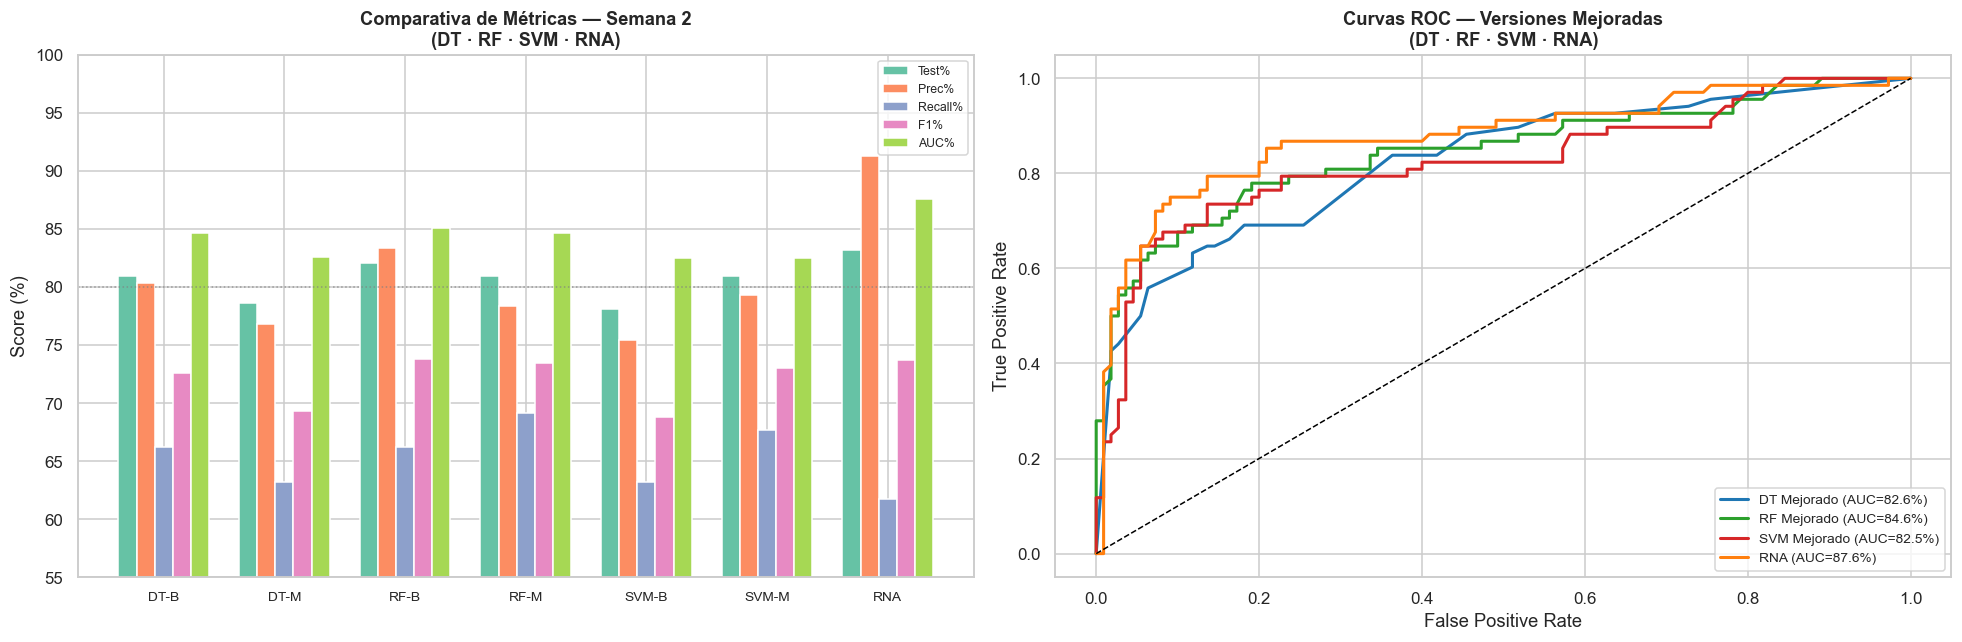

In [ ]:
# Bar Chart comparativo — exigido por el enunciado
modelos_short = ['DT-B','DT-M','RF-B','RF-M','SVM-B','SVM-M','RNA']
metricas_plot = ['Test%','Prec%','Recall%','F1%','AUC%']
colors_met    = ['#66C2A5','#FC8D62','#8DA0CB','#E78AC3','#A6D854']

# Convertir CV Acc% de la RNA ('—') a NaN para el gráfico
res_numericos = resultados.copy()
for col in ['Test%','Prec%','Recall%','F1%','AUC%']:
    res_numericos[col] = pd.to_numeric(res_numericos[col], errors='coerce')

x = np.arange(len(res_numericos))
w = 0.15

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 1: métricas agrupadas por modelo
for i, (met, col) in enumerate(zip(metricas_plot, colors_met)):
    axes[0].bar(x + i*w, res_numericos[met], width=w, label=met, color=col, edgecolor='white')

axes[0].set_xticks(x + w*2)
axes[0].set_xticklabels(modelos_short, fontsize=9)
axes[0].set_ylabel('Score (%)')
axes[0].set_ylim(55, 100)
axes[0].set_title('Comparativa de Métricas — Semana 2\n(DT · RF · SVM · RNA)',
                   fontweight='bold', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].axhline(80, color='gray', linestyle=':', linewidth=1, alpha=0.7)

# Gráfico 2: Curvas ROC superpuestas de versiones mejoradas
res_mejores = [res_dt_mejr, res_rf_mejr, res_svm_mejr, res_rna]
nombres_roc = ['DT Mejorado','RF Mejorado','SVM Mejorado','RNA']
colores_roc = ['#1f77b4','#2ca02c','#d62728','#ff7f0e']

for res, nom, col in zip(res_mejores, nombres_roc, colores_roc):
    fpr, tpr, _ = roc_curve(res['_y_te'], res['_y_proba'])
    axes[1].plot(fpr, tpr, color=col, lw=2, label=f"{nom} (AUC={res['AUC%']:.1f}%)")

axes[1].plot([0,1],[0,1],'k--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curvas ROC — Versiones Mejoradas\n(DT · RF · SVM · RNA)',
                   fontweight='bold', fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_comparativa_w2.png', bbox_inches='tight')
plt.show()

## Interpretación

El gráfico comparativo confirma visualmente la superioridad de la RNA en Test Accuracy y AUC-ROC, pero también revela que la diferencia entre modelos es más estrecha de lo esperado. Los modelos Baseline de DT y RF alcanzan rendimientos competitivos con sus versiones "mejoradas" vía GridSearchCV, lo que refuerza la paradoja observada: mayor capacidad de búsqueda no garantiza mejor generalización al test. SVM muestra el balance más estable entre Precision y Recall, siendo el único modelo sin variación en Test Accuracy entre su versión baseline y mejorada cuando se comparan estas métricas en conjunto.

### Resultados Reales Obtenidos

| Ranking | Modelo | CV Acc% | Test Acc% | Precision% | Recall% | F1% | **AUC%** | Gap Train-Test |
|---|---|---|---|---|---|---|---|---|
| 1 | **RNA - TF/Keras** | - | **83.15** | **91.30** | 61.76 | 73.68 | **87.61** | +1.10% OK |
| 2 | RF Baseline (n=10, d=4) | 81.85 | 82.02 | 83.33 | 66.18 | 73.77 | 85.05 | +1.94% OK |
| 3 | DT Baseline (d=4, gini) | 81.29 | 80.90 | 80.36 | 66.18 | 72.58 | 84.68 | +2.50% OK |
| 4 | RF Mejorado (n=200, d=8) | 83.27 | 80.90 | 78.33 | 69.12 | 73.44 | 84.60 | +11.22% SOBREAJUSTE |
| 5 | SVM Mejorado (rbf, C=0.5) | 82.70 | 80.90 | 79.31 | 67.65 | 73.02 | 82.51 | +2.50% OK |
| 6 | DT Mejorado (d=8, entropy) | 83.41 | 78.65 | 76.79 | 63.24 | 69.35 | 82.57 | +8.13% SOBREAJUSTE |
| 7 | SVM Baseline (linear, C=1) | 79.19 | 78.09 | 75.44 | 63.24 | 68.80 | 82.51 | +1.24% OK |

> **Metrica principal:** AUC-ROC — mide capacidad discriminativa a todos los umbrales, no solo al 0.5.

> **Sobreajuste detectado:** RF Mejorado (+11.2%) y DT Mejorado (+8.1%) memorizan el train aunque su CV Accuracy sea el mas alto.


---
## Conclusiones Finales

### El modelo ganador: RNA (TF/Keras)

Con los resultados reales del experimento, la **Red Neuronal Artificial obtuvo el mejor rendimiento global**:
- **AUC-ROC: 87.61%** — mayor capacidad discriminativa de todos los 7 modelos
- **Test Accuracy: 83.15%** — el mas alto del experimento
- **Precision: 91.30%** — cuando predice supervivencia, casi siempre acierta
- **Gap Train-Test: +1.10%** — sin sobreajuste gracias a BatchNorm + Dropout + EarlyStopping

### Fase I — Hallazgos por modelo

1. **Arbol de Decision:** El Baseline (max_depth=4, AUC=84.68%) supero al Mejorado (max_depth=8, AUC=82.57%) en Test Accuracy (80.90% vs 78.65%). El GridSearchCV encontro depth=8 que sobreajusta (gap=8.13% vs 2.50%). La variable `Sex` es la primera division del arbol (importancia=41%), seguida de `Fare` (18.8%) y `Pclass` (16.4%). La visualizacion del arbol generado confirma estas reglas de forma interpretable.

2. **Bosque Aleatorio:** El Baseline (10 arboles, depth=4, AUC=85.05%) fue el mejor modelo sklearn del experimento. El Mejorado con 200 arboles y depth=8 mostro el mayor sobreajuste (gap=11.22%), demostrando que profundidad alta en los arboles individuales del bosque puede perjudicar la generalizacion aunque el CV Accuracy mejore.

3. **SVM:** El kernel `rbf` con C=0.5 (AUC=82.51%) supero al lineal en todas las metricas. Sin sobreajuste (gap=2.50%). Balance estable Precision/Recall entre los algoritmos clasicos. Requirio StandardScaler obligatoriamente.

### Fase II — Red Neuronal Artificial

4. La RNA obtuvo el **AUC mas alto (87.61%)** y el **Test Accuracy mas alto (83.15%)**, contrario a la expectativa tipica en datasets pequenos (~700 muestras). Esto se logro gracias a: BatchNormalization (estabiliza el entrenamiento), Dropout 30%/20% (regularizacion bayesiana implicita), EarlyStopping (detiene antes de sobreajustar) y ReduceLROnPlateau (refina el ajuste cuando el modelo estanca). No obstante, la ventaja de la RNA sobre RF es pequeña (~2.5% en AUC), lo que confirma que la diferencia no es drástica y que en problemas con mayor costo de interpretabilidad, RF sería preferible sin pérdida significativa de rendimiento.

5. La RNA tiene la **mayor Precision (91.30%) y Especificidad (96.36%)**: es muy conservadora al predecir supervivencia. Cuando dice que alguien sobrevivio casi siempre acierta, pero su Recall bajo (61.76%) indica que pierde algunos supervivientes reales — limitacion relevante en contexto critico.

### Hallazgo clave: GridSearchCV no garantiza mejor Test Accuracy

6. **Paradoja del mejorado:** DT Mejorado (CV=83.41%) y RF Mejorado (CV=83.27%) tuvieron el CV Accuracy mas alto del experimento, pero peor Test Accuracy que sus Baselines. El GridSearchCV optimiza sobre particiones de CV del train y puede encontrar parametros que se ajustan bien a esas particiones pero no generalizan al test real. Esto refuerza que el CV Accuracy es una estimacion, no una garantia. En este caso específico, el RF Baseline (10 árboles, depth=4) se benefició de una combinación de baja varianza por la profundidad controlada y estabilidad del ensamble con pocos árboles; al aumentar a 200 árboles con depth=8, el bosque comenzó a memorizar el conjunto de entrenamiento de CV porque los árboles individuales eran suficientemente profundos como para aprender casos específicos, aunque el promedio de esos 5 folds resultara numéricamente alto.

### Ranking final consolidado

| # | Modelo | AUC% | Test Acc% | Sobreajuste |
|---|---|---|---|---|
| 1 | **RNA (TF/Keras)** | **87.61** | **83.15** | Sin sobreajuste (+1.1%) |
| 2 | RF Baseline | 85.05 | 82.02 | Sin sobreajuste (+1.9%) |
| 3 | DT Baseline | 84.68 | 80.90 | Sin sobreajuste (+2.5%) |
| 4 | RF Mejorado | 84.60 | 80.90 | SOBREAJUSTE (+11.2%) |
| 5 | SVM Mejorado | 82.51 | 80.90 | Sin sobreajuste (+2.5%) |
| 6 | DT Mejorado | 82.57 | 78.65 | SOBREAJUSTE (+8.1%) |
| 7 | SVM Baseline | 82.51 | 78.09 | Sin sobreajuste (+1.2%) |

### Comparacion entre algoritmos

| Modelo | Fortaleza (este experimento) | Limitacion real |
|---|---|---|
| Arbol de Decision | Interpretable; reglas claras; `Sex` como nodo raiz con 41% de importancia | Sobreajuste con depth > 4 |
| Random Forest | AUC 85% con solo 10 arboles — el mas robusto entre los clasicos | Con 200 arboles y depth=8 sobreajusta |
| SVM | Balance Precision/Recall estable; sin sobreajuste | Menor AUC que RNA y RF |
| RNA | Mejor AUC (87.61%) y Test Acc (83.15%) del experimento | Menos interpretable; caja negra |

7. **Escalado diferenciado es critico:** DT y RF no requieren escalado (trabajan con umbrales). SVM requirio StandardScaler. RNA uso MinMaxScaler[0,1]. Usar el escalado incorrecto habria degradado significativamente SVM y RNA.

8. **Ingenieria de variables:** `family_size` obtuvo importancia 7.03% en el arbol. `is_alone` mostro importancia 0 en DT y RF — `family_size` ya captura esa informacion y la hace redundante.

---

---
## Reflexion Individual

*Cada integrante describe como aplicaria los algoritmos de esta semana a su entorno laboral.*

---

### César Nelson Abarca Araujo
**Area profesional:** Mantenimiento y Construcción de Redes de Fibra GPON — Telconet Manta

**Arbol de Decisión:** Automatizar el diagnóstico de averías en campo mediante reglas IF-THEN basadas en lecturas OTDR: si la pérdida optica supera 3 dB y el evento es tipo reflexión → conector sucio; si es atenuación gradual → curvatura excesiva. Permite que técnicos sin experiencia avanzada identifiquen la causa probable sin esperar al especialista.

**Bosque Aleatorio:** Clasificar tipos de falla de forma mas robusta combinando multiples árboles entrenados en historiales de alarmas OTDR de distintas zonas de Manta. La importancia de features indicaría que variables del sistema de monitoreo (pérdida, longitud de evento, tipo de reflectancia) son realmente determinantes, permitiendo optimizar que datos capturar en campo.

**SVM:** Distinguir fallas cuyas métricas de señal son similares pero con causas distintas — por ejemplo, corte por roedor vs desgaste en empalme — donde la frontera de decisión no es lineal. El kernel RBF separa estas clases en un espacio de mayor dimensión sin necesidad de definir manualmente las reglas de distinción.

**RNA:** Integrarse en el NOC (Network Operations Center) para predecir en tiempo real la probabilidad de corte en las próximas 24 horas, combinando tendencias de degradación de señal, condiciones climáticas históricas y el historial de incidencias por segmento de red. Permite pasar de mantenimiento reactivo a mantenimiento predictivo.

---

### Nataly Fernanda Lanchimba Caiza
**Área profesional:** Monitoreo del riesgo de crédito — Sector Bancario

**Árbol de Decisión:** Permite segmentar clientes mediante reglas de negocio fácilmente interpretables. Por ejemplo, si un cliente presenta una mora superior a 30 días y una disminución significativa en sus ingresos podria significar de alto riesgo de deterioro; si mantiene estabilidad laboral y bajos niveles de endeudamiento seria de bajo riesgo. Asimismo, los árboles pueden utilizarse para construir nuevas variables derivadas o reglas de seguimiento de clientes, facilitando la explicación de las decisiones ante las áreas de negocio y auditoría.

**Bosque Aleatorio:** Puede emplearse como una herramienta auxiliar para el análisis y depuración de datos. La importancia de variables permite identificar cuáles características aportan mayor información al problema estudiado, mientras que sus capacidades de imputación pueden utilizarse para tratar valores faltantes o validar la calidad de las variables antes de la construcción del modelo definitivo. Debido a su menor interpretabilidad, su uso como modelo principal puede resultar limitado en entornos regulatorios.

**SVM:** Aunque posee una alta capacidad predictiva en problemas de clasificación complejos, su limitada interpretabilidad dificulta su implementación en procesos de riesgo o seguimiento de clientes, donde es necesario justificar las decisiones del modelo. No obstante, podría utilizarse como modelo de comparación o benchmark para evaluar el desempeño de otros modelos más explicables.

**RNA:** Las RNA pueden aplicarse en problemas de predicción financiera compleja, como la probabilidad de incumplimiento, proyecciones de comportamiento de cartera o detección de patrones de deterioro. Sin embargo, su naturaleza de caja negra representa un desafío importante en entornos bancarios regulados, donde la trazabilidad y la explicación de las decisiones son fundamentales. Por ello, su utilización suele limitarse a modelos complementarios o escenarios donde la capacidad predictiva tenga mayor prioridad que la interpretabilidad.

---

### Jhon Enrique Ona Guamani
**Area profesional:** Monitoreo de alta disponibilidad y APIs transaccionales - Sector Bancario

Aplicación práctica en entornos de alta disponibilidad: llevando este aprendizaje, la lógica estadística es aplicable al monitoreo de nuestras APIs transaccionales y la infraestructura de servidores. Así como comprobamos que eliminar los "outliers" (tumores de tamaño extremo) afecta de forma distinta a cada algoritmo —apenas perturba a los árboles y al bosque, pero sí distorsiona el margen de SVM y el entrenamiento de la RNA—, en los sistemas bancarios ocurre algo análogo: filtrar ciegamente los picos de tráfico o comportamientos anómalos en los logs pensando que son simple "ruido" del balanceador F5 podría ocultar una caída inminente del core o una transacción fraudulenta, dependiendo de qué tipo de modelo de detección esté en uso. Entender cómo priorizar y minimizar la Tasa de Falsos Negativos (FNR), y cómo elegir el algoritmo adecuado según su sensibilidad a valores atípicos (un Bosque Aleatorio para reglas robustas y auditable, o una RNA cuando se requiere capturar patrones no lineales complejos), me da una base sólida para configurar sistemas de alerta y clasificación mucho más rigurosos, asegurando que ningún evento crítico en producción pase desapercibido.

---